In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')
 
import kmapper as km
import umap
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import DBSCAN
from scipy import stats
import networkx as nx
from ripser import ripser
from persim import plot_diagrams
 
os.makedirs("outputs", exist_ok=True)
plt.rcParams['figure.dpi'] = 120

In [18]:
df = pd.read_csv("data/dataset2_limpio.csv")
print(f"Shape original: {df.shape}")
 
numeric_cols = [
    'Edad madre', 'PN hijo (g)', 'EG hijo (sem)', 'Dif peso mamá', 'IMC antes',
    'mgAF/día SAF', 'mgAF/día período MAF', 'mgAF/día OSAF 1°T', 'mg/d AF total pan',
    'Código SAF', 'Código MAF', 'Código OSAF', 'Código alimentos', 'Código pan',
    'Código pan/día consumido', 'Patología RN', 'Período consumo SAF+OSAF',
    'Código consumo SIN', 'Días consumo suplementosAF'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = (pd.to_numeric(
            df[col].astype(str).str.replace(',', '.'), errors='coerce')
            .fillna(0))
 
df['¿Hijo nace c/problema de salud?'] = (
    pd.to_numeric(df['¿Hijo nace c/problema de salud?'], errors='coerce')
    .fillna(0).astype(int))
 
print(f"Shape final: {df.shape}")
print(f"\nDistribución Patología RN:\n{df['Patología RN'].value_counts().sort_index()}")


Shape original: (705, 67)
Shape final: (705, 67)

Distribución Patología RN:
Patología RN
0    653
1     12
2      6
3      9
4      5
5      3
6      4
7      3
8      2
9      8
Name: count, dtype: int64


In [19]:
"""df[df.af_total < 400].describe()"""

'df[df.af_total < 400].describe()'

## 2. Ingeniería de Features — Taxonomía de Suplementos
 
### SAF — Ácido Fólico Puro (sin B12, códigos 1–16)
| Código | Nombre | Dosis | B12 | Riesgo trampa |
|:---|:---|:---|:---:|:---|
| 1,4,6,8,10 | Folacid/Folisanin/Folvit/Heliofol/Miliser 1mg | 1 000 μg | ❌ | ALTO |
| 2,3,5,7,9,11,15 | Versiones 5mg | 5 000 μg | ❌ | MUY ALTO |
| 12 | Fersitol 1 sobre | ~400 μg | ❌ | MEDIO |
| 13 | Del consultorio | ~1 000 μg | ❌ | ALTO |
 
### OSAF — AF + Hierro u otros (códigos 17–26)
| Código | Nombre | Composición | B12 | Riesgo |
|:---|:---|:---|:---:|:---|
| 17 | Cheltin FC | Hierro quelato 30 mg + AF 600 μg | ❌ | MEDIO-ALTO |
| 18,21 | Folifer / Hemofolic | Hierro ferroso + AF | ❌ | MEDIO-ALTO |
| 24 | MAAM vit | Multivitamínico (probable B12) | ✅ | BAJO |
| 26 | Exelmyo  | myo-inositol + AF (contraindicado embarazo) | ❌ | ALTO + anómalo |
 
### MAF — Multivitamínicos con B12  (códigos 27–41)
Supradyn Prenatal (27), Centrum (28), Bion 3 (29), Regenesis (30–32),  
Femasvit (33), Gintol (34), Gestavit (35), Infor pro vegan (36),  
Naticare (37–39), Prenamin natal (40), Vitakron duo (41)
 
> **Codificación `Código alimentos` en el dataset limpio:**  
> 1 = Evitó animales (riesgo B12), 2 = Evitó gluten/trigo, 3 = Evitó otros, 4 = No evitó nada
""")
 

In [20]:
df['Total mg/d DFE suple y pan'].describe()

count    705.000000
mean       4.022858
std        3.408551
min        0.043000
25%        1.802000
50%        2.142000
75%        8.611000
max       13.192000
Name: Total mg/d DFE suple y pan, dtype: float64

In [21]:
df["mgAF/día SAF"].describe()

count    705.000000
mean       1.851159
std        1.967876
min        0.000000
25%        0.571000
50%        1.000000
75%        5.000000
max        5.000000
Name: mgAF/día SAF, dtype: float64

In [22]:

MAF_CODES    = list(range(27, 42))   # 27=Supradyn…41=Vitakron duo
OSAF_B12     = [24]                  # MAAM vit — probable B12
OSAF_ANOMALO = [26]                  # Exelmyo — contraindicado en embarazo
UL_AF        = 1000                  # μg/día — Upper Level tolerable
 
# ── 1. Total AF diario (μg/día) ──────────────────────────────────────────────
"""df['af_total'] = (
    df['mgAF/día SAF'] +
    df['mgAF/día período MAF'] +
    df['mgAF/día OSAF 1°T'] +
    df['mg/d AF total pan']
) * 1000
"""
df['af_total'] = df['Total mg/d AF  suple y pan']*1000
# ── 2. B12: ¿tiene MAF con B12? ───────────────────────────────────────

df['b12_via_supp'] = df['Código MAF'].isin(MAF_CODES).astype(int)
 
# ── 3. Riesgo B12 dietario: evitó alimentos animales ─────────────────────────
# Código alimentos 1 = animales
df['b12_diet_risk'] = (df['Código alimentos'] == 1).astype(int)
 
# ── 4. Score de trampa de folato (continuo) ──────────────────────────────────
df["trap_score"] = (
    (df["mgAF/día SAF"] * 1000 / UL_AF) *   # solo la fracción sintética
    (1 + df["b12_diet_risk"] * 0.5) *
    (1 - df["b12_via_supp"]  * 0.7)
).clip(lower=0)
 
# ── 5. Binarios de exposición ─────────────────────────────────────────────────
df['over_ul']      = (df['af_total'] > UL_AF).astype(int)
df['pure_fa_only'] = ((df['Código SAF'] > 0) & (df['Código MAF'] == 0)).astype(int)
 
# ── 6. Suplemento anómalo (Exelmyo, contraindicado en embarazo) ──────────────
df['supp_anomalo'] = df['Código OSAF'].isin(OSAF_ANOMALO).astype(int)
 
# ── 7. Timing: suplementación durante el embarazo ────────────────────────────
# Período consumo: 1=solo antes(eliminar), 2=1T, 3=todo embarazo, 4=no consumió

df['supp_1T']       = (df['Período consumo SAF+OSAF'] == 2).astype(int)
df['supp_completo'] = (df['Período consumo SAF+OSAF'] == 3).astype(int)
df['supp_durante']  = (df['supp_1T'] | df['supp_completo']).astype(int)
 
# ── 8. Tipos de SAF ───────────────────────────────────────────────────────────
df['saf_5mg']    = df['Código SAF'].isin([2,3,5,7,9,11,15]).astype(int)
df['saf_1mg']    = df['Código SAF'].isin([1,4,6,8,10,12,13,14,16]).astype(int)
df['osaf_hierro']= df['Código OSAF'].isin([17,18,19,20,21,22,25]).astype(int)
df['supp_sin_af']= (df['Código consumo SIN'] > 0).astype(int)
 
# ── 9. Alimentos evitados (one-hot) ──────────────────────────────────────────
# Código alimentos: 1=animales, 2=gluten, 3=otros, 4=nada
df['evito_animal'] = (df['Código alimentos'] == 1).astype(int)
df['evito_gluten'] = (df['Código alimentos'] == 2).astype(int)
df['evito_otros']  = (df['Código alimentos'] == 3).astype(int)
df['no_evito']     = (df['Código alimentos'] == 4).astype(int)
 
# ── 10. Flag trampa de folato (AF alto + sin B12) ────────────────────────────
df['folate_trap_flag'] = ((df['af_total'] > UL_AF) & (df['b12_via_supp'] == 0)).astype(int)
 
# ── 11. Patologías agrupadas ──────────────────────────────────────────────────
# Código Patología RN: 1=alergia,2=TEA,3=cardíaca,4=pulmonar,5=digestiva,
#                      6=renal,7=PEG,8=prematuro,9=malformación,10=parálisis
PATOL_SEVERA      = [2, 3, 9, 10]   # TEA, cardíaca, malformación, parálisis
PATOL_CRECIMIENTO = [7, 8]          # PEG, prematuro
df['patologia_any']         = df['¿Hijo nace c/problema de salud?']
df['patologia_severa']      = df['Patología RN'].isin(PATOL_SEVERA).astype(int)
df['patologia_crecimiento'] = df['Patología RN'].isin(PATOL_CRECIMIENTO).astype(int)
 
print("Features construidos")
print(f"  Trampa de folato (flag): {df['folate_trap_flag'].sum()} ({df['folate_trap_flag'].mean()*100:.1f}%)")
print(f"  Con B12 via suplemento:  {df['b12_via_supp'].sum()} ({df['b12_via_supp'].mean()*100:.1f}%)")
print(f"  Evitaron alim. animales: {df['evito_animal'].sum()} ({df['evito_animal'].mean()*100:.1f}%)")
print(f"  AF total media:          {df['af_total'].mean():.0f} μg/día")
print(f"  Sobre el UL (>1000):     {df['over_ul'].sum()} ({df['over_ul'].mean()*100:.1f}%)")
print(f"  Exelmyo (anómalo):       {df['supp_anomalo'].sum()}")


Features construidos
  Trampa de folato (flag): 358 (50.8%)
  Con B12 via suplemento:  265 (37.6%)
  Evitaron alim. animales: 171 (24.3%)
  AF total media:          2366 μg/día
  Sobre el UL (>1000):     557 (79.0%)
  Exelmyo (anómalo):       0


## 3. Eda nuevas variables

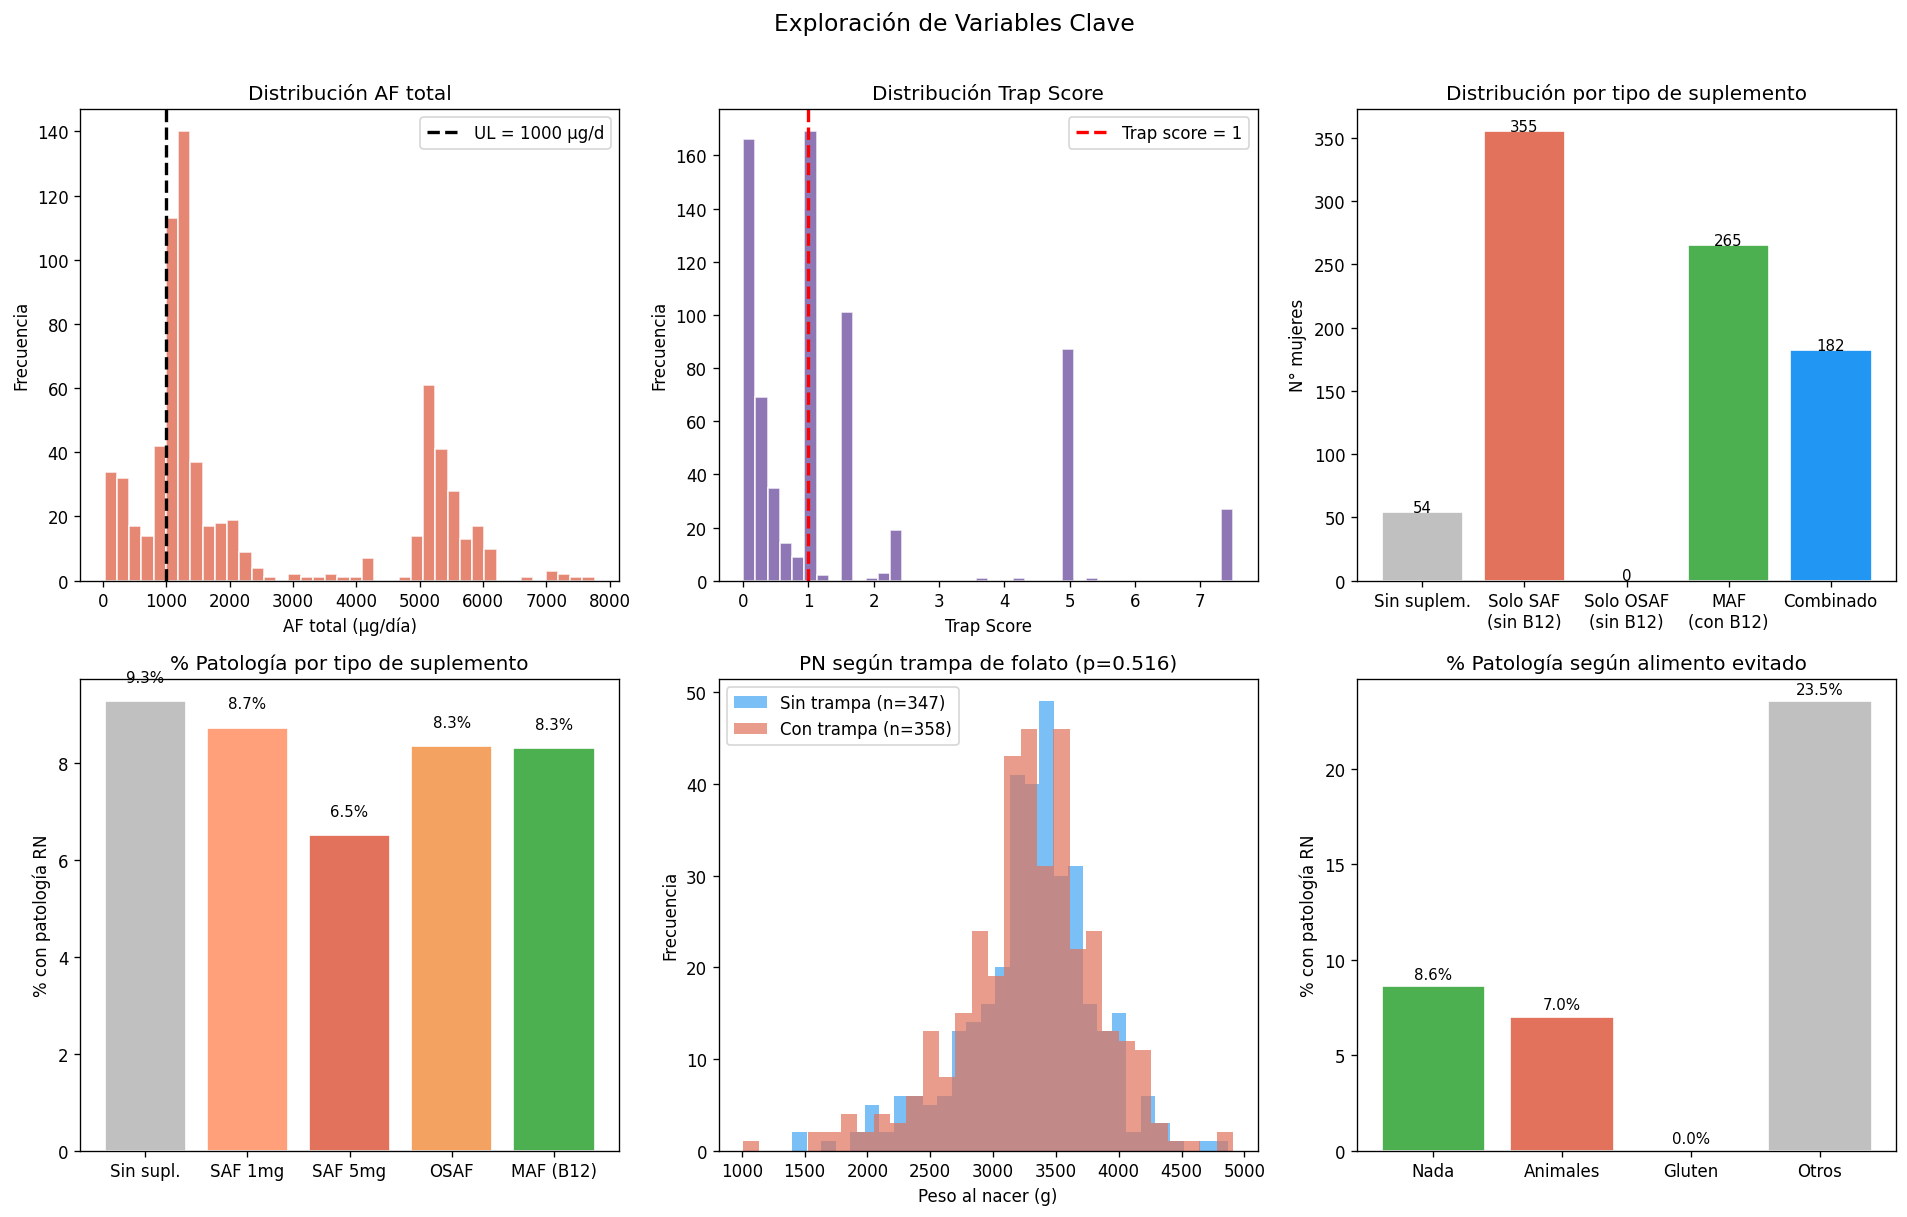

EDA guardado en outputs/eda_resumen.png


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exploración de Variables Clave", fontsize=14, y=1.01)
 
# 1. Distribución AF total
ax = axes[0, 0]
ax.hist(df['af_total'].clip(0, 8000), bins=40, color="#E2725B", edgecolor="white", alpha=0.85)
ax.axvline(UL_AF, color="black", linestyle="--", lw=2, label=f"UL = {UL_AF} μg/d")
ax.set_xlabel("AF total (μg/día)"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución AF total"); ax.legend()
 
# 2. Trap score
ax = axes[0, 1]
ax.hist(df['trap_score'].clip(0, 15), bins=40, color="#7B5EA7", edgecolor="white", alpha=0.85)
ax.axvline(1, color="red", linestyle="--", lw=2, label="Trap score = 1")
ax.set_xlabel("Trap Score"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución Trap Score"); ax.legend()
 
# 3. N por tipo de suplemento
ax = axes[0, 2]
grupos = {
    "Sin suplem.": ((df["Código SAF"]==0)&(df["Código MAF"]==0)&(df["Código OSAF"]==0)).sum(),
    "Solo SAF\n(sin B12)": ((df["Código SAF"]>0)&(df["Código MAF"]==0)).sum(),
    "Solo OSAF\n(sin B12)": ((df["Código OSAF"]>0)&(df["Código SAF"]==0)&(df["Código MAF"]==0)).sum(),
    "MAF\n(con B12)": df["Código MAF"].isin(MAF_CODES).sum(),
    "Combinado": ((df["Código SAF"]>0)&df["Código MAF"].isin(MAF_CODES)).sum(),
}
colors = ["#C0C0C0","#E2725B","#F4A261","#4CAF50","#2196F3"]
bars = ax.bar(grupos.keys(), grupos.values(), color=colors, edgecolor="white")
for b, v in zip(bars, grupos.values()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, str(int(v)), ha='center', fontsize=9)
ax.set_ylabel("N° mujeres"); ax.set_title("Distribución por tipo de suplemento")
 
# 4. % patología por tipo de suplemento
ax = axes[1, 0]
g_labels = ["Sin supl.", "SAF 1mg","SAF 5mg","OSAF","MAF (B12)"]
masks = [
    (df["Código SAF"]==0)&(df["Código MAF"]==0),
    df["saf_1mg"]==1, df["saf_5mg"]==1,
    df["osaf_hierro"]==1, df["b12_via_supp"]==1
]
pcts = [df.loc[m,"patologia_any"].mean()*100 for m in masks]
c2 = ["#C0C0C0","#FFA07A","#E2725B","#F4A261","#4CAF50"]
b2 = ax.bar(g_labels, pcts, color=c2, edgecolor="white")
for b, v in zip(b2, pcts):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}%", ha='center', fontsize=9)
ax.set_ylabel("% con patología RN"); ax.set_title("% Patología por tipo de suplemento")
 
# 5. PN por estado de trampa
ax = axes[1, 1]
pn_trap = df.loc[df['folate_trap_flag']==1,'PN hijo (g)'].dropna()
pn_ok   = df.loc[df['folate_trap_flag']==0,'PN hijo (g)'].dropna()
ax.hist(pn_ok,  bins=30, alpha=0.6, color="#2196F3", label=f"Sin trampa (n={len(pn_ok)})")
ax.hist(pn_trap,bins=30, alpha=0.7, color="#E2725B", label=f"Con trampa (n={len(pn_trap)})")
ax.set_xlabel("Peso al nacer (g)"); ax.set_ylabel("Frecuencia")
if len(pn_trap)>2 and len(pn_ok)>2:
    _, p = stats.mannwhitneyu(pn_trap, pn_ok, alternative="two-sided")
    ax.set_title(f"PN según trampa de folato (p={p:.3f})")
else:
    ax.set_title("PN según trampa de folato")
ax.legend()
 
# 6. % patología según alimento evitado
ax = axes[1, 2]
ev_labels = ["Nada","Animales","Gluten","Otros"]
ev_cols   = ["no_evito","evito_animal","evito_gluten","evito_otros"]
pcts2 = [df.loc[df[c]==1,"patologia_any"].mean()*100 for c in ev_cols]
c3 = ["#4CAF50","#E2725B","#F4A261","#C0C0C0"]
b3 = ax.bar(ev_labels, pcts2, color=c3, edgecolor="white")
for b, v in zip(b3, pcts2):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}%", ha='center', fontsize=9)
ax.set_ylabel("% con patología RN"); ax.set_title("% Patología según alimento evitado")
 
plt.tight_layout()
plt.savefig("outputs/eda_resumen.png", bbox_inches="tight")
plt.show()
print("EDA guardado en outputs/eda_resumen.png")


## Nuevos espacios

In [24]:
AF_FEATURES = [
    'af_total', 'mgAF/día SAF', 'mgAF/día período MAF', 'mg/d AF total pan',
    'Días consumo suplementosAF', 'trap_score',
    'b12_via_supp', 'b12_diet_risk',
    'saf_5mg', 'saf_1mg', 'osaf_hierro',
    'supp_completo', 'supp_1T', 'supp_sin_af'
]
OUT_FEATURES = [
    'PN hijo (g)', 'EG hijo (sem)', 'Dif peso mamá', 'IMC antes',
    'patologia_any', 'Patología RN', 'patologia_severa', 'patologia_crecimiento'
]
FOOD_FEATURES = [
    'mg/d AF total pan', 'evito_animal', 'evito_gluten', 'evito_otros', 'no_evito',
    'Código pan/día consumido', 'supp_sin_af', 'b12_via_supp', 'b12_diet_risk'
]
 
def build_space(df, features, scaler='robust'):
    X = df[features].fillna(0).values
    sc = RobustScaler() if scaler == 'robust' else StandardScaler()
    return sc.fit_transform(X)
 
X_af   = build_space(df, AF_FEATURES,   scaler='robust')
X_out  = build_space(df, OUT_FEATURES,  scaler='standard')
X_food = build_space(df, FOOD_FEATURES, scaler='robust')
X_comb = np.hstack([X_af, X_out])
 
print("Espacios construidos:")
for name, X in [("X_af", X_af), ("X_out", X_out), ("X_comb", X_comb)]:
    print(f"  {name}: {X.shape}")


Espacios construidos:
  X_af: (705, 14)
  X_out: (705, 8)
  X_comb: (705, 22)


## 5. Análisis Topológico — Mapper
 
Cuatro configuraciones con diferentes lentes:
 
| Mapper | Lente | Datos | Objetivo |
|:---|:---|:---|:---|
| **A** | `trap_score` | Combinado | Identificar mujeres en zona de riesgo |
| **B** | `af_total` | Outcomes | Gradiente de dosis → outcomes |
| **C** | `PN hijo (g)` | Espacio AF | Outcomes → qué patrón de AF lo precede |
| **D** | UMAP(hábitos) | Outcomes | Hábitos alimenticios → salud bebé |

 

In [25]:
mapper = km.KeplerMapper(verbose=0)
 
# ── MAPPER A: lente = trap_score ──────────────────────────────────────────────
print("Ejecutando Mapper A (lente: trap_score)...")
lens_A = df[['trap_score']].values
 
graph_A = mapper.map(
    lens_A, X_comb,
    clusterer=DBSCAN(eps=1.5, min_samples=3),
    cover=km.Cover(n_cubes=8, perc_overlap=0.4)
)
 
try:
    mapper.visualize(graph_A,
        title="Mapper A: Trampa de Folato",
        color_values=df['patologia_any'].values,
        color_function_name="% patología RN",
        path_html="outputs/mapper_A_trampa_folato.html")
except Exception as e:
    print(f"  HTML no generado: {e}")
 
print(f"Mapper A: {len(graph_A['nodes'])} nodos")


Ejecutando Mapper A (lente: trap_score)...
Mapper A: 17 nodos


In [26]:
# ── MAPPER B: lente = af_total (gradiente de dosis → outcomes) ───────────────
print("Ejecutando Mapper B (lente: af_total)...")
lens_B = df[['af_total']].values
 
graph_B = mapper.map(
    lens_B, X_out,
    clusterer=DBSCAN(eps=1.2, min_samples=3),
    cover=km.Cover(n_cubes=8, perc_overlap=0.35)
)
 
try:
    mapper.visualize(graph_B,
        title="Mapper B: Gradiente AF → Outcomes",
        color_values=df['PN hijo (g)'].values,
        color_function_name="Peso al nacer (g)",
        path_html="outputs/mapper_B_gradiente_af.html")
except Exception as e:
    print(f"  HTML no generado: {e}")
 
print(f"Mapper B: {len(graph_B['nodes'])} nodos")

Ejecutando Mapper B (lente: af_total)...
Mapper B: 14 nodos


In [27]:
# ── MAPPER C: lente = PN (outcomes → perfil AF) ───────────────────────────────
print("Ejecutando Mapper C (lente: PN hijo)...")
pn_val = df['PN hijo (g)'].fillna(df['PN hijo (g)'].median()).values.reshape(-1,1)
lens_C = StandardScaler().fit_transform(pn_val)
 
graph_C = mapper.map(
    lens_C, X_af,
    clusterer=DBSCAN(eps=1.2, min_samples=3),
    cover=km.Cover(n_cubes=8, perc_overlap=0.35)
)
 
try:
    mapper.visualize(graph_C,
        title="Mapper C: Peso al Nacer → Perfil AF",
        color_values=df['trap_score'].values,
        color_function_name="Trap score",
        path_html="outputs/mapper_C_lente_invertida.html")
except Exception as e:
    print(f"  HTML no generado: {e}")
 
print(f"Mapper C: {len(graph_C['nodes'])} nodos")


Ejecutando Mapper C (lente: PN hijo)...
Mapper C: 49 nodos


In [28]:
# ── MAPPER C: lente = PN (outcomes → perfil AF) ───────────────────────────────
print("Ejecutando Mapper C (lente: PN hijo)...")
pn_val = df['PN hijo (g)'].fillna(df['PN hijo (g)'].median()).values.reshape(-1,1)
lens_C = StandardScaler().fit_transform(pn_val)
 
graph_C = mapper.map(
    lens_C, X_af,
    clusterer=DBSCAN(eps=1.2, min_samples=3),
    cover=km.Cover(n_cubes=8, perc_overlap=0.35)
)
 
try:
    mapper.visualize(graph_C,
        title="Mapper C: Peso al Nacer → Perfil AF",
        color_values=df['trap_score'].values,
        color_function_name="Trap score",
        path_html="outputs/mapper_C_lente_invertida.html")
except Exception as e:
    print(f"  HTML no generado: {e}")
 
print(f"Mapper C: {len(graph_C['nodes'])} nodos")


Ejecutando Mapper C (lente: PN hijo)...
Mapper C: 49 nodos


In [29]:
# ── MAPPER D: lente = UMAP(hábitos) → outcomes ───────────────────────────────
print("Ejecutando Mapper D (lente: UMAP hábitos alimenticios)...")
reducer_d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
lens_D = reducer_d.fit_transform(X_food)
 
graph_D = mapper.map(
    lens_D, X_out,
    clusterer=DBSCAN(eps=1.2, min_samples=3),
    cover=km.Cover(n_cubes=8, perc_overlap=0.4)
)
 
try:
    mapper.visualize(graph_D,
        title="Mapper D: Hábitos Alimenticios → Salud RN",
        color_values=df['patologia_any'].values,
        color_function_name="% Patología RN",
        path_html="outputs/mapper_D_habitos_salud.html")
except Exception as e:
    print(f"  HTML no generado: {e}")
 
print(f"Mapper D: {len(graph_D['nodes'])} nodos")
print("\nHTMLs interactivos guardados en outputs/")


Ejecutando Mapper D (lente: UMAP hábitos alimenticios)...
Mapper D: 43 nodos

HTMLs interactivos guardados en outputs/


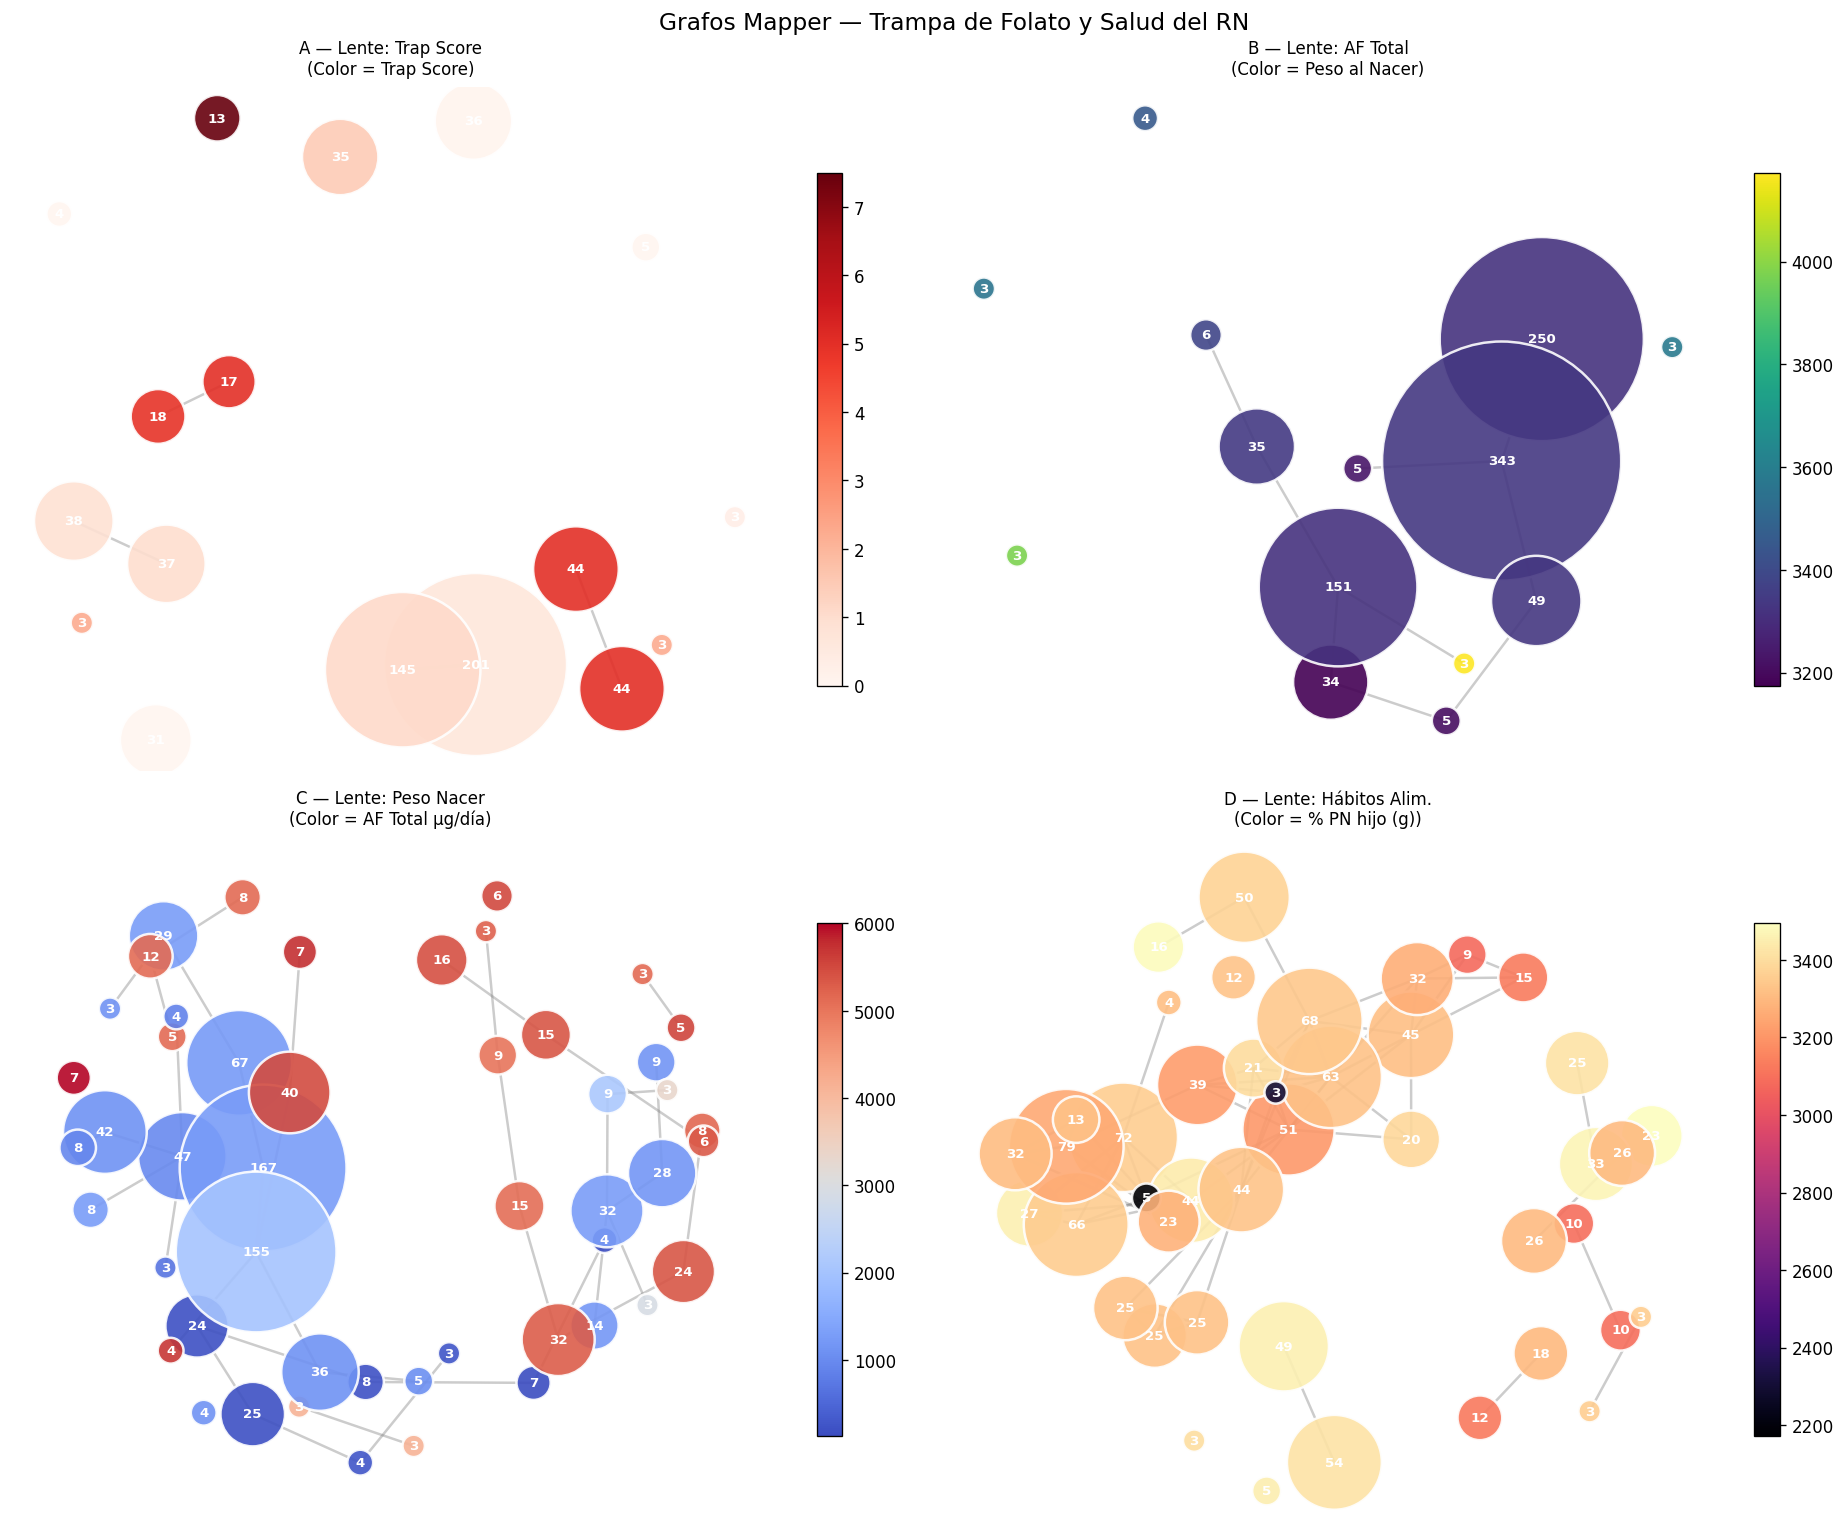

Panel guardado en outputs/mappers_4panel.png


In [30]:
def graficar_mapper(graph_dict, df, color_feat, title, cmap="viridis", size_mult=60):
    if not graph_dict["nodes"]:
        print(f"Grafo vacío: {title}")
        return None, None
    G = nx.Graph()
    nsz, ncol, nlbl = [], [], {}
    for nid, idx in graph_dict["nodes"].items():
        G.add_node(nid)
        nsz.append(max(len(idx)*size_mult, 80))
        ncol.append(df.iloc[idx][color_feat].mean())
        nlbl[nid] = str(len(idx))
    for src_n, tgts in graph_dict["links"].items():
        for tgt in tgts:
            G.add_edge(src_n, tgt)
    return G, (nsz, ncol, nlbl)
 
def dibujar(G, props, title, cmap, ax):
    if G is None:
        ax.text(0.5, 0.5, "Grafo vacío", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.set_title(title, fontsize=10); ax.axis("off"); return
    nsz, ncol, nlbl = props
    pos = nx.spring_layout(G, k=0.6, seed=42)
    vmin, vmax = min(ncol), max(ncol)
    nodes = nx.draw_networkx_nodes(G, pos, node_size=nsz, node_color=ncol,
                cmap=plt.get_cmap(cmap), alpha=0.9, edgecolors="white",
                linewidths=1.5, vmin=vmin, vmax=vmax, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.4, width=1.5, edge_color="gray", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=nlbl, font_size=8,
                            font_color="white", font_weight="bold", ax=ax)
    sm = cm.ScalarMappable(cmap=plt.get_cmap(cmap),
                           norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.75)
    ax.set_title(title, fontsize=10, pad=8); ax.axis("off")
 
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle("Grafos Mapper — Trampa de Folato y Salud del RN", fontsize=14)
 
configs = [
    (graph_A, "trap_score",   "A — Lente: Trap Score\n(Color = Trap Score)",         "Reds",    axes[0,0]),
    (graph_B, "PN hijo (g)",  "B — Lente: AF Total\n(Color = Peso al Nacer)",         "viridis", axes[0,1]),
    (graph_C, "af_total",     "C — Lente: Peso Nacer\n(Color = AF Total μg/día)",     "coolwarm",axes[1,0]),
    (graph_D, "PN hijo (g)" ,"D — Lente: Hábitos Alim.\n(Color = % PN hijo (g))",   "magma",   axes[1,1]),
]
for graph, feat, title, cmap, ax in configs:
    G, props = graficar_mapper(graph, df, feat, title, cmap=cmap)
    dibujar(G, props, title, cmap, ax)
 
plt.tight_layout()
plt.savefig("outputs/mappers_4panel.png", bbox_inches="tight", dpi=150)
plt.show()
print("Panel guardado en outputs/mappers_4panel.png")

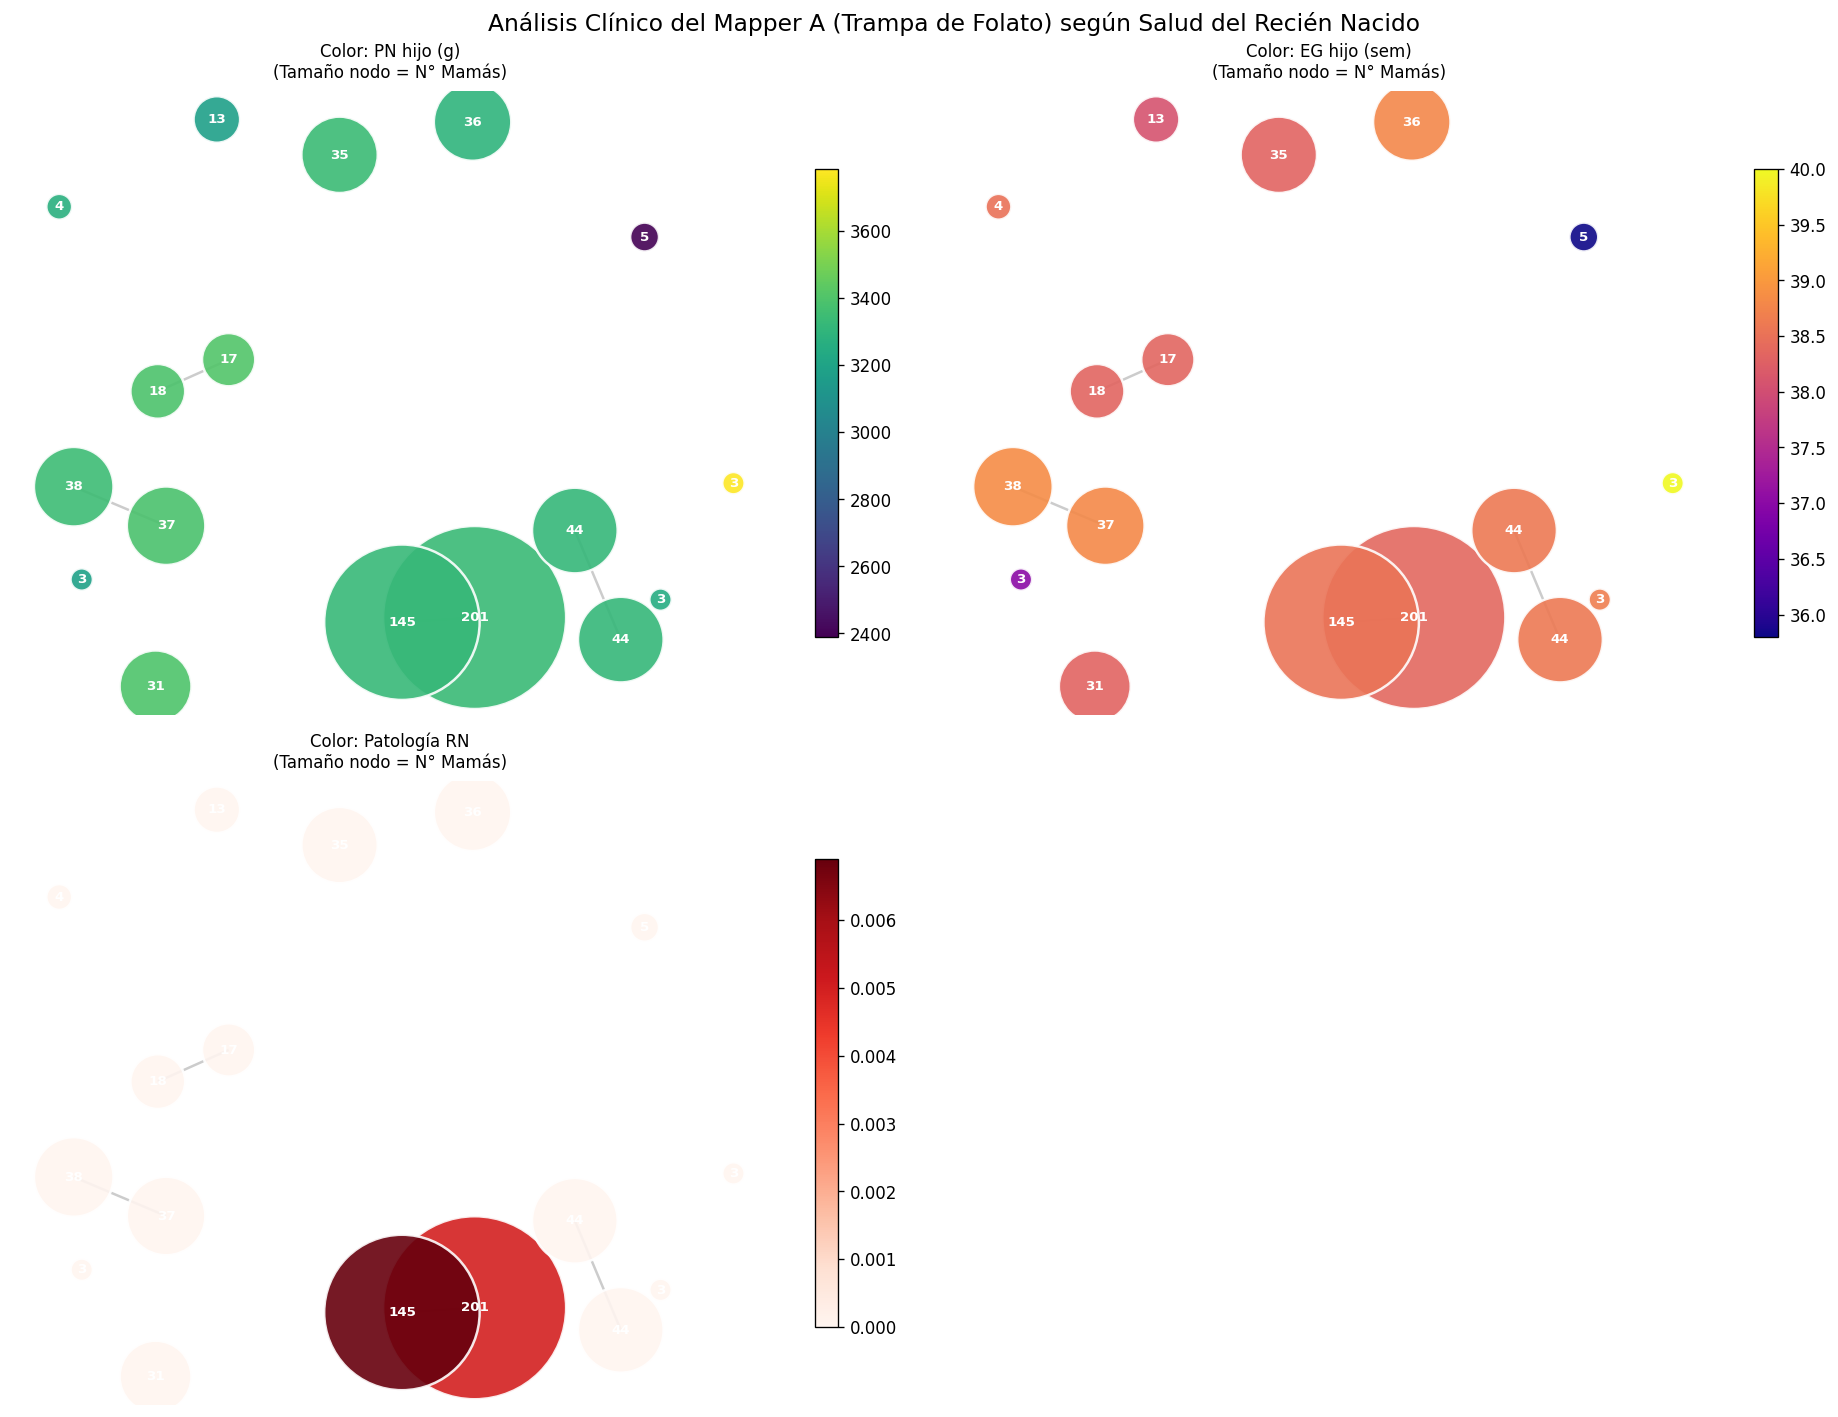

Análisis guardado con éxito en: outputs/analisis_mapper_a_(trampa_de_folato)_outcomes.png


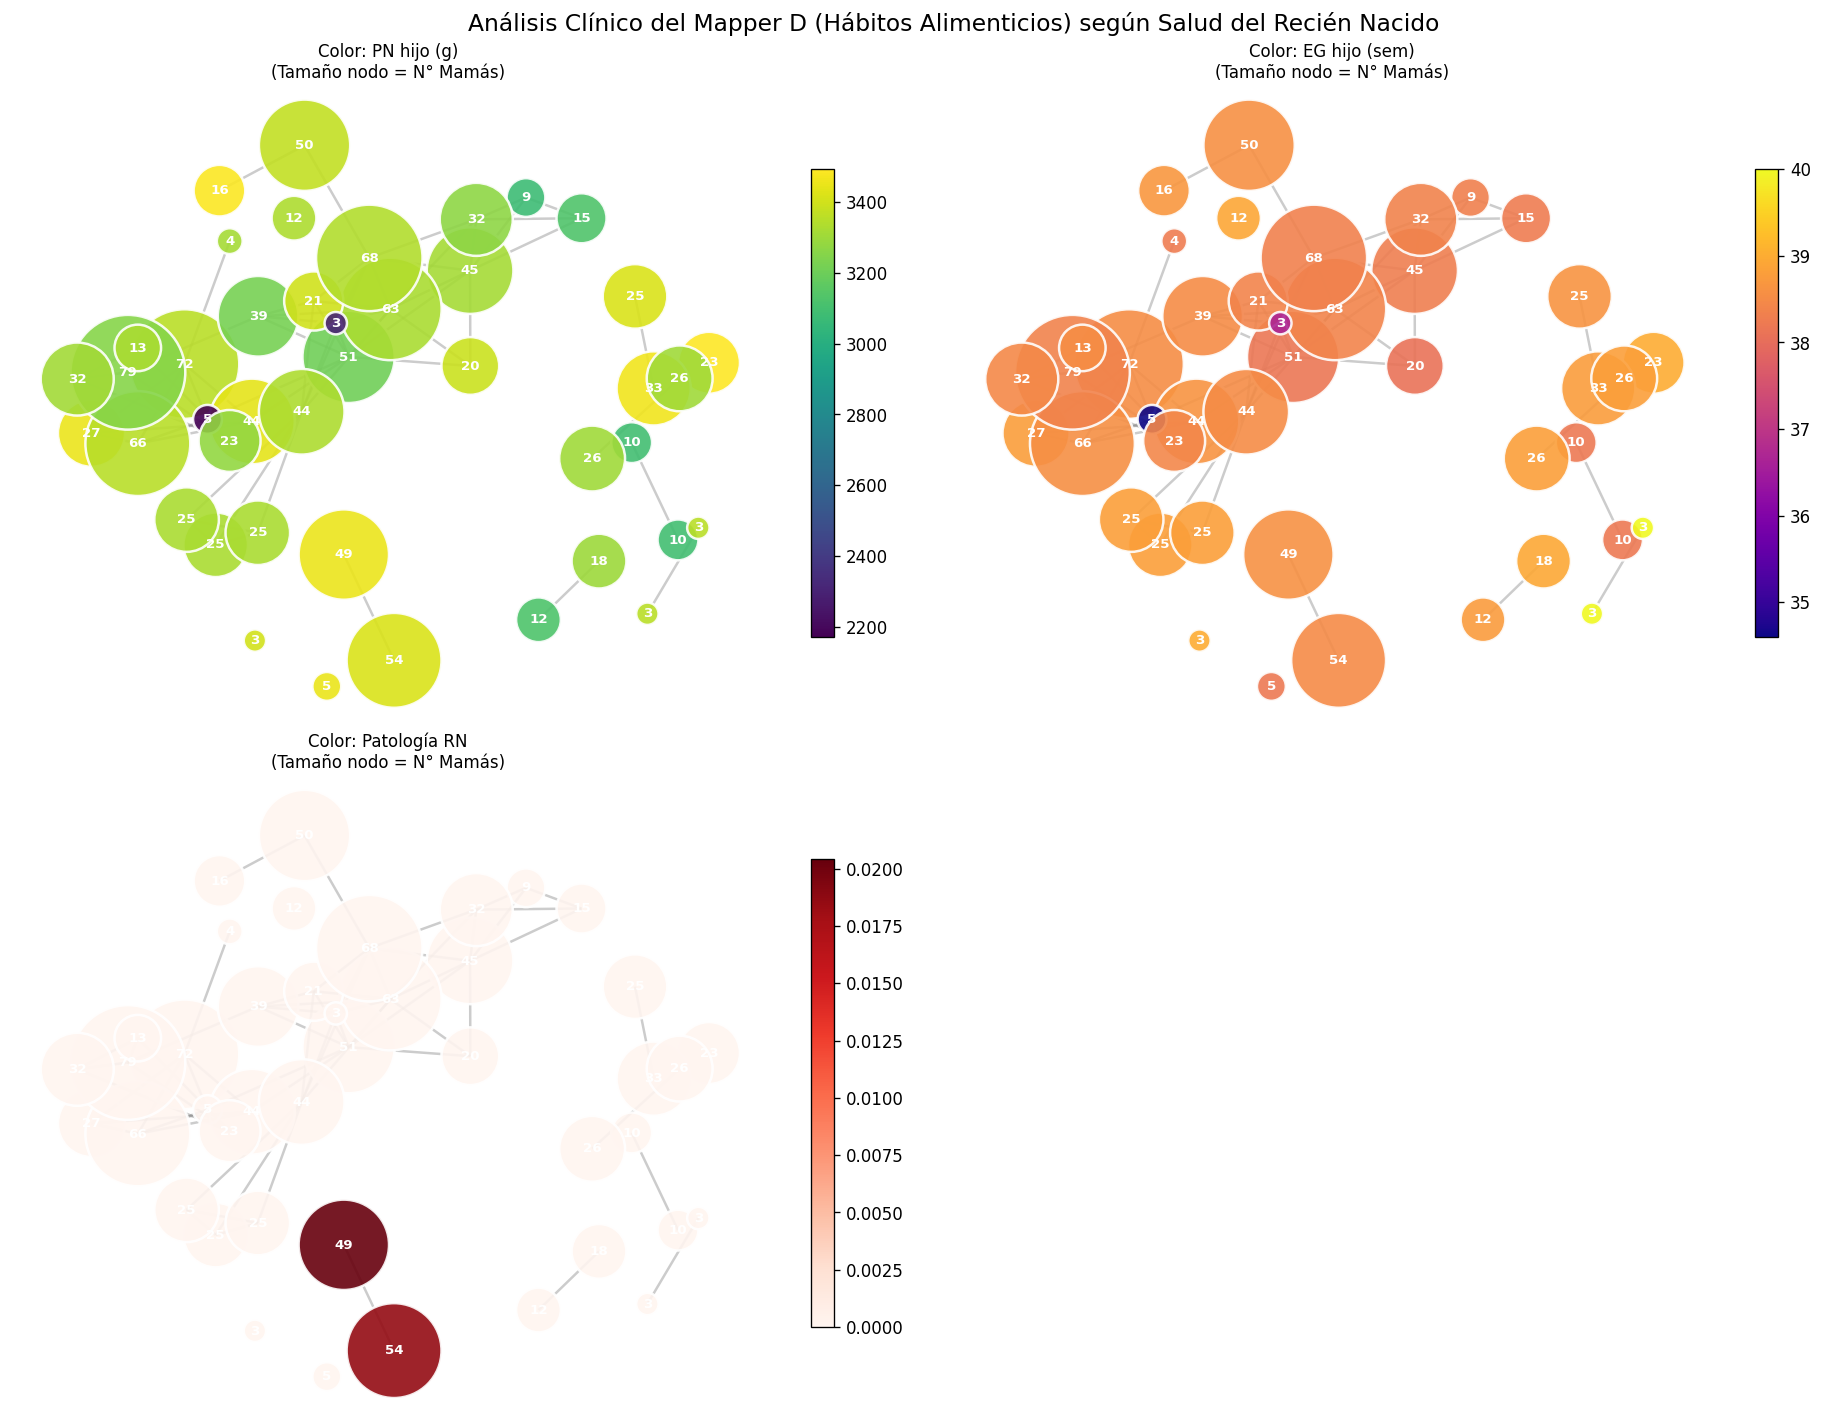

Análisis guardado con éxito en: outputs/analisis_mapper_d_(hábitos_alimenticios)_outcomes.png


In [31]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

def analizar_mapper_con_outcomes(graph_dict, df, out_features_to_plot, mapper_name="Mapper"):
    """
    Toma un grafo de Mapper ya calculado y genera un panel de subplots 
    coloreado por diferentes variables de salida (salud del bebé) para ver su distribución.
    """
    # Validar que el grafo tenga nodos
    if not graph_dict or not graph_dict["nodes"]:
        print(f"El grafo {mapper_name} está vacío. No se puede analizar.")
        return

    # Configuramos una cuadrícula automática (ej. 2x2 para 4 variables)
    n_feats = len(out_features_to_plot)
    cols = 2
    rows = (n_feats + 1) // 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
    fig.suptitle(f"Análisis Clínico del {mapper_name} según Salud del Recién Nacido", fontsize=14, y=0.98)
    axes = axes.flatten() # Aplanar para iterar fácilmente

    # Paletas de color estratégicas: 'viridis' para continuas, 'YlOrRd' o 'Reds' para patologías/riesgos
    cmaps_config = {
        'PN hijo (g)': 'viridis',
        'EG hijo (sem)': 'plasma',
        'Patología RN': 'Reds',
    }

    for i, feat in enumerate(out_features_to_plot):
        ax = axes[i]
        
        # Elegir paleta por defecto si no está en la configuración
        cmap = cmaps_config.get(feat, 'magma')
        
        # Crear título limpio
        title = f"Color: {feat}\n(Tamaño nodo = N° Mamás)"
        
        # Reutilizar tus funciones existentes para extraer propiedades y dibujar
        G, props = graficar_mapper(graph_dict, df, feat, title, cmap=cmap)
        dibujar(G, props, title, cmap, ax)

    # Ocultar ejes sobrantes si el número de variables es impar
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    
    # Crear directorio de salida si no existe
    os.makedirs("outputs", exist_ok=True)
    filename = f"outputs/analisis_{mapper_name.lower().replace(' ', '_')}_outcomes.png"
    plt.savefig(filename, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Análisis guardado con éxito en: {filename}")


variables_salud_rn = [
    'PN hijo (g)',            # Peso al nacer (Continuo)
    'EG hijo (sem)',           # Edad gestacional (Continuo)
    'Patología RN',          # % Cualquier patología 
]

# 2. Aplicar el análisis al MAPPER A (Trampa de Folato Directa)
# Esto te permitirá ver si el grupo con "Alto Score de Trampa" concentra bebés con patologías o bajo peso
analizar_mapper_con_outcomes(
    graph_dict=graph_A, 
    df=df, 
    out_features_to_plot=variables_salud_rn, 
    mapper_name="Mapper A (Trampa de Folato)"
)

# 3. Aplicar el análisis al MAPPER D (Hábitos alimenticios)
# Esto te permitirá ver si los clusters definidos por la dieta impactan en el peso o prematurez
analizar_mapper_con_outcomes(
    graph_dict=graph_D, 
    df=df, 
    out_features_to_plot=variables_salud_rn, 
    mapper_name="Mapper D (Hábitos Alimenticios)"
)

In [32]:
# ═══════════════════════════════════════════════════════════════════════════
#  ANÁLISIS: TRAP SCORE → SALUD NEONATAL
#  Marco teórico: Castaño et al., Rev Chil Pediatr 2017;88(2):199-206
#  UL_AF = 1000 μg/día (Institute of Medicine, 1998)
# ═══════════════════════════════════════════════════════════════════════════

# ─── Cortes clínicos justificados por el paper ──────────────────────────────
# score = (af_total / UL) * modulador_B12
# score < 0.5  → ingesta < 50% UL, B12 puede compensar → sin trampa
# score 0.5–1  → zona gris, cerca del UL
# score > 1.0  → supera el UL: trampa activa (el paper lo llama "condición de riesgo")
# score > 1.5  → trampa severa: >150% UL + B12 comprometida


from scipy.stats import kruskal, spearmanr, chi2_contingency
import pandas as pd
import numpy as np

UMBRAL_GRIS   = 0.5
UMBRAL_TRAP   = 1.0   # ← el UL del paper
UMBRAL_SEVERA = 1.5

df["trap_tier"] = pd.cut(
    df["trap_score"],
    bins=[-np.inf, UMBRAL_GRIS, UMBRAL_TRAP, UMBRAL_SEVERA, np.inf],
    labels=["BAJO", "GRIS", "TRAMPA", "SEVERA"]
)

tBAJO   = df[df["trap_tier"] == "BAJO"]
tGRIS   = df[df["trap_tier"] == "GRIS"]
tTRAPA  = df[df["trap_tier"] == "TRAMPA"]
tSEVERA = df[df["trap_tier"] == "SEVERA"]

# ─── Outcomes del paper: peso, EG, PEG, prematuro ──────────────────────────
# El paper menciona específicamente: bajo peso al nacer, prematurez,
# PEG (pequeño para edad gestacional) como outcomes asociados al desbalance
# folatos/B12 (refs 3, 7, 20, 21 del paper)

has_path = (df["patologia_any"] == 1) if "patologia_any" in df.columns \
           else (df["Patología RN"] > 0)

print("── OUTCOMES NEONATALES POR PERFIL DE TRAMPA ────────────────────────────")
print("   (ref: Castaño et al. 2017 — bajo peso, prematurez, PEG)")
print()
fmt = "{:<28} {:>10} {:>10} {:>10} {:>10}   {:>8}  {}"
print(fmt.format("Outcome", "BAJO", "GRIS", "TRAMPA", "SEVERA", "p KW", "sig"))
print("-" * 90)

grupos = [tBAJO, tGRIS, tTRAPA, tSEVERA]
nombres = ["BAJO", "GRIS", "TRAMPA", "SEVERA"]

for col, label, tipo in [
    ("PN hijo (g)",   "Peso neonatal (g)",     "continua"),
    ("EG hijo (sem)", "Edad gestacional (sem)", "continua"),
    ("patologia_any", "Cualquier patología %",  "binaria"),
    ("patologia_severa","Patología severa %",   "binaria"),
]:
    if col not in df.columns:
        continue
    
    if tipo == "continua":
        medias = [g[col].mean() for g in grupos]
        stat, p = kruskal(*[g[col].dropna() for g in grupos])
        sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
        print(fmt.format(label,
              *[f"{m:.1f}" for m in medias], f"{p:.4f}", sig))
    else:
        pcts = [g[col].mean()*100 for g in grupos]
        combined = pd.concat([g[[col]].assign(tier=n) 
                              for g, n in zip(grupos, nombres)])
        ct = pd.crosstab(combined["tier"], combined[col])
        chi2, p, _, _ = chi2_contingency(ct)
        sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
        print(fmt.format(label,
              *[f"{pct:.1f}%" for pct in pcts], f"{p:.4f}", sig))

# ─── Correlación de Spearman (continua, sin categorizar) ────────────────────
print("\n── CORRELACIÓN SPEARMAN: trap_score (continuo) ↔ outcomes ─────────────")
print("   (detecta relación dosis-respuesta lineal)")
for col, label in [("PN hijo (g)","Peso"), ("EG hijo (sem)","EG"),
                   ("patologia_any","Patología (0/1)")]:
    if col not in df.columns: continue
    r, p = spearmanr(df["trap_score"], df[col], nan_policy="omit")
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    direction = "↓ score alto = peor" if r < 0 else "↑ score alto = peor"
    print(f"  {label:<22}  ρ = {r:+.3f}   p = {p:.4f}  {sig}   {direction}")

# ─── Análisis de interacción: trampa × B12 ──────────────────────────────────
# El paper (p.202): "una elevada ingesta de AF podría conducir a deficiencia
# de B12" — la B12 amplifica o atenúa el daño
print("\n── INTERACCIÓN TRAMPA × DÉFICIT B12 ────────────────────────────────────")
print("   (el paper: desbalance folatos/B12 altera metilación DNA fetal)")

df["trampa_activa"] = (df["trap_score"] > UMBRAL_TRAP).astype(int)
df["sin_b12"]       = (df["b12_via_supp"] == 0).astype(int)

for col, label in [("PN hijo (g)", "Peso promedio (g)"),
                   ("patologia_any", "% patología")]:
    if col not in df.columns: continue
    print(f"\n  {label}:")
    tabla = df.groupby(["trampa_activa","sin_b12"])[col].mean()
    print(f"    {'':25}  con supp B12   sin supp B12")
    for trap_val, trap_label in [(0,"Score ≤ UL (sin trampa)"),
                                  (1,"Score > UL (trampa activa)")]:
        v_con = tabla.get((trap_val, 0), float("nan"))
        v_sin = tabla.get((trap_val, 1), float("nan"))
        if col == "patologia_any":
            print(f"    {trap_label:<25}  {v_con*100:6.1f}%         {v_sin*100:6.1f}%")
        else:
            print(f"    {trap_label:<25}  {v_con:6.1f}           {v_sin:6.1f}")

# ─── Dose-response por deciles ───────────────────────────────────────────────
print("\n── DOSE-RESPONSE: patología por decil de trap_score ────────────────────")
df["trap_decile"] = pd.qcut(df["trap_score"], q=10,
                            labels=False, duplicates="drop") + 1
dec = df.groupby("trap_decile").agg(
    n=("trap_score","count"),
    trap_mean=("trap_score","mean"),
    pct_pat=(has_path.name if hasattr(has_path,"name") else "patologia_any",
             lambda x: x.mean()*100)
).reset_index()
print(dec.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

── OUTCOMES NEONATALES POR PERFIL DE TRAMPA ────────────────────────────
   (ref: Castaño et al. 2017 — bajo peso, prematurez, PEG)

Outcome                            BAJO       GRIS     TRAMPA     SEVERA       p KW  sig
------------------------------------------------------------------------------------------
Peso neonatal (g)                3283.1     3274.9     3348.9     3302.1     0.9942  ns
Edad gestacional (sem)             38.2       38.2       38.8       38.0     0.1358  ns
Cualquier patología %              9.6%       9.4%       6.5%       6.6%     0.6200  ns
Patología severa %                 4.4%       3.6%       2.2%       1.5%     0.3412  ns

── CORRELACIÓN SPEARMAN: trap_score (continuo) ↔ outcomes ─────────────
   (detecta relación dosis-respuesta lineal)
  Peso                    ρ = -0.027   p = 0.4813  ns   ↓ score alto = peor
  EG                      ρ = -0.003   p = 0.9265  ns   ↓ score alto = peor
  Patología (0/1)         ρ = -0.053   p = 0.1593  ns   ↓ score a

In [40]:
df["mgAF/día SAF"].describe()

count    705.000000
mean       1.851159
std        1.967876
min        0.000000
25%        0.571000
50%        1.000000
75%        5.000000
max        5.000000
Name: mgAF/día SAF, dtype: float64

In [42]:
df.columns

Index(['Unnamed: 0', 'n', 'Fecha encuesta', 'Edad madre', 'Nacionalidad',
       'Agrupación nacionalidad', 'Región', 'Educación', 'FN hijo', 'Período',
       'N° embarazo', 'Sexo hijo', 'PN hijo (g)', 'EG hijo (sem)',
       'KG inicio mamá', 'KG fin mamá', 'Dif peso mamá', 'Estatura mamá',
       'IMC antes', 'IMC después', 'Dif IMC', 'Condición mamá',
       '¿Hijo nace c/problema de salud?', 'Patología RN',
       '¿Consume suplementos y/o multivitamínico de AF en embarazo?',
       '¿Consume SAF?', '¿Consume SAF+OSAF?', 'Código SAF',
       'mgAF/cáp SAF+OSAF', '¿Cuántos días de SAF?', '¿Cuántas cáp SAF?',
       'mgAF/día SAF', '¿Consumió MAF?', '¿Consumió MAF completo?',
       'Código MAF', 'mgAF/cáp MAF', '¿Cuántos días de MAF?',
       '¿Cuántas cáp MAF?', 'mgAF/día MAF 1°T', 'Consumo OSAF 1° toma',
       'Consumo OSAF 2° toma', 'Consumo OSAF completo', 'Código OSAF',
       'mgAF/cáp OSAF', '¿Cuántos días de OSAF?', '¿Cuántas cáp OSAF?',
       'mgAF/día OSAF 1°T', 'mgAF/d

In [45]:
df["Total mg/d AF  suple y pan"].describe()

count    705.000000
mean       2.366365
std        2.005022
min        0.025000
25%        1.060000
50%        1.260000
75%        5.065000
max        7.760000
Name: Total mg/d AF  suple y pan, dtype: float64

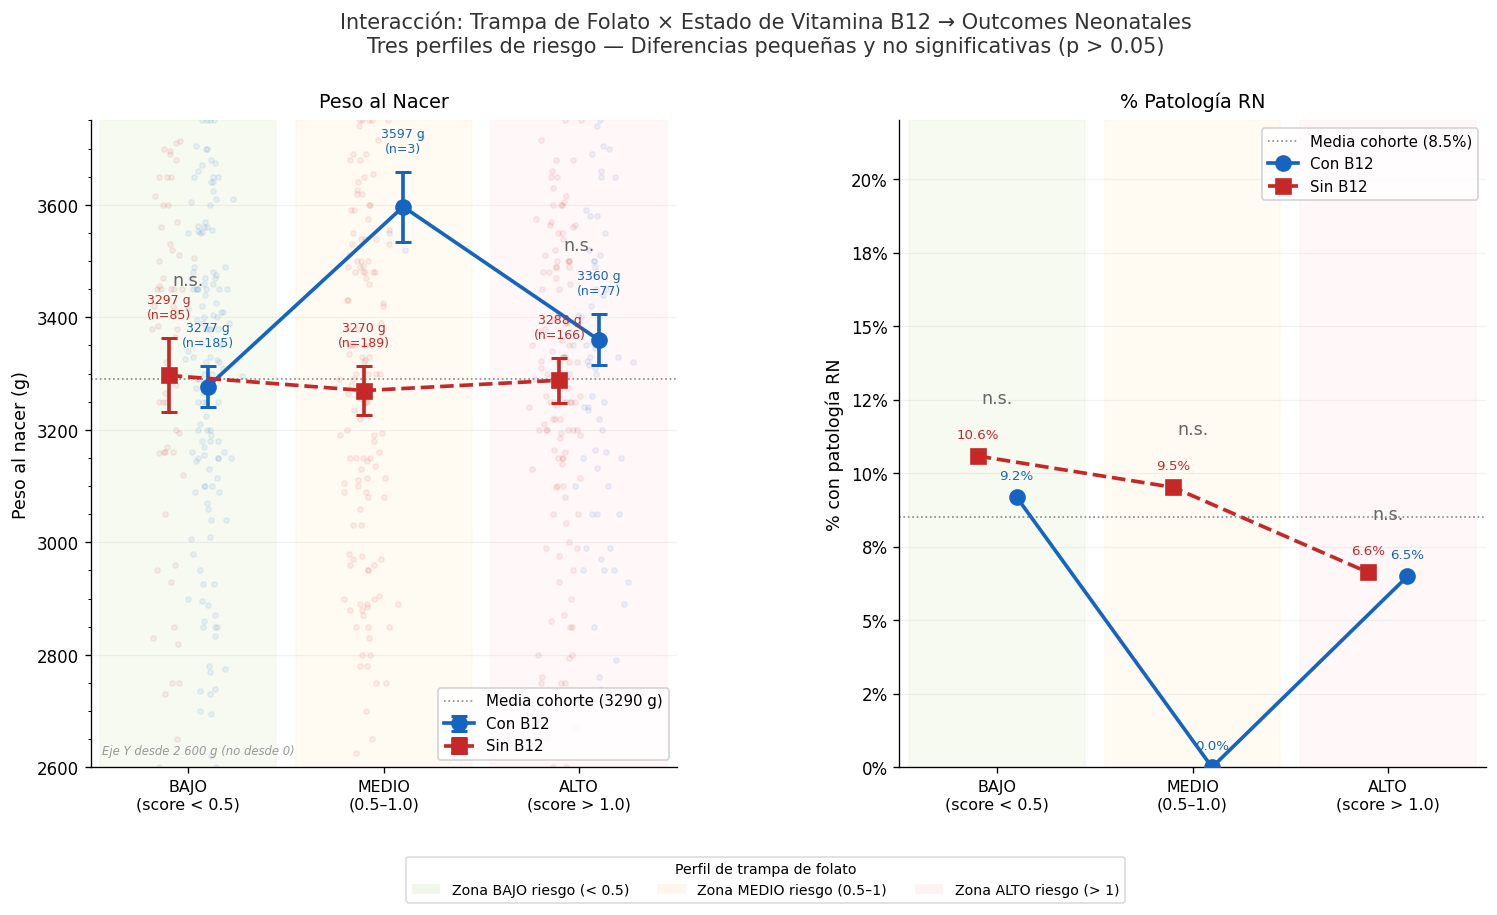

Gráfico guardado en outputs/interaccion_trampa_b12_3perfiles.png

── TABLA DE VALORES ────────────────────────────────────────────────────
                                   Con B12     Sin B12         Δ  p
------------------------------------------------------------------------

  Perfil BAJO:
    Peso al nacer (g)                3276.8      3296.7    -19.9g  n.s.
    % Patología RN                     9.2%       10.6%     -1.4pp n.s.
    n (Con B12 / Sin B12)               185          85

  Perfil MEDIO:
    Peso al nacer (g)                3596.7      3269.8   +326.9g  n.s.
    % Patología RN                     0.0%        9.5%     -9.5pp n.s.
    n (Con B12 / Sin B12)                 3         189

  Perfil ALTO:
    Peso al nacer (g)                3360.1      3288.2    +71.9g  n.s.
    % Patología RN                     6.5%        6.6%     -0.1pp n.s.
    n (Con B12 / Sin B12)                77         166

Nota: Δ = Con B12 − Sin B12  |  n.s. = no significativo (p > 0.05)
Los

In [ ]:
"""
Visualización: Interacción Trampa de Folato × Estado de B12 → Outcomes Neonatales
3 perfiles de riesgo (BAJO / MEDIO / ALTO)
Marco teórico: Castaño et al., Rev Chil Pediatr 2017;88(2):199-206
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from scipy.stats import mannwhitneyu, chi2_contingency

# ─── 0. Parámetros de los 3 perfiles de trampa ─────────────────────────────
BAJO_MAX  = 0.5
MEDIO_MAX = 1.0

df["trap_tier3"] = pd.cut(
    df["trap_score"],
    bins=[-np.inf, BAJO_MAX, MEDIO_MAX, np.inf],
    labels=["BAJO", "MEDIO", "ALTO"],
)

TIER_ORDER  = ["BAJO", "MEDIO", "ALTO"]
TIER_XLBLS  = [
    f"BAJO\n(score < {BAJO_MAX})",
    f"MEDIO\n({BAJO_MAX}–{MEDIO_MAX})",
    f"ALTO\n(score > {MEDIO_MAX})",
]
TIER_BG     = {"BAJO": "#EAF3DE", "MEDIO": "#FFF3E0", "ALTO": "#FFEBEE"}  # fondo suave
B12_STYLE   = {
    "Con B12":  dict(color="#1565C0", marker="o", ls="-",  lw=2.2, ms=9,  offset=+0.10),
    "Sin B12":  dict(color="#C62828", marker="s", ls="--", lw=2.2, ms=9,  offset=-0.10),
}

# ─── 1. Calcular estadísticas por celda (tier × B12) ───────────────────────
def cell_stats(tier, b12_mask):
    mask = (df["trap_tier3"] == tier) & b12_mask
    sub  = df[mask]
    pn   = sub["PN hijo (g)"].dropna()
    pat  = sub["patologia_any"].dropna() if "patologia_any" in sub.columns \
           else (sub["Patología RN"] > 0).dropna()
    return dict(
        n      = len(sub),
        pn_mean= pn.mean(),
        pn_sem = pn.sem(),
        pn_vals= pn.values,
        pat_pct= pat.mean() * 100,
        pat_n  = int(pat.sum()),
        pat_vals= pat.values,
    )

B12_MASKS = {
    "Con B12": df["b12_via_supp"] == 1,
    "Sin B12": df["b12_via_supp"] == 0,
}

cells = {(t, b): cell_stats(t, B12_MASKS[b])
         for t in TIER_ORDER for b in B12_MASKS}

# ─── 2. Tests estadísticos por tier (Mann-Whitney / chi-cuadrado) ───────────
def mwu_p(tier, col):
    a = df[(df["trap_tier3"] == tier) & B12_MASKS["Con B12"]][col].dropna()
    b = df[(df["trap_tier3"] == tier) & B12_MASKS["Sin B12"]][col].dropna()
    if len(a) < 2 or len(b) < 2:
        return 1.0
    _, p = mannwhitneyu(a, b, alternative="two-sided")
    return p

def chi2_p(tier):
    combined = pd.concat([
        df[(df["trap_tier3"] == tier) & B12_MASKS["Con B12"]][["patologia_any"]].assign(b12=1),
        df[(df["trap_tier3"] == tier) & B12_MASKS["Sin B12"]][["patologia_any"]].assign(b12=0),
    ])
    ct = pd.crosstab(combined["b12"], combined["patologia_any"])
    if ct.shape[1] < 2:
        return 1.0
    try:
        _, p, _, _ = chi2_contingency(ct)
    except Exception:
        p = 1.0
    return p

def annot(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

pn_ps  = {t: mwu_p(t, "PN hijo (g)")  for t in TIER_ORDER}
pat_ps = {t: chi2_p(t)                 for t in TIER_ORDER}

# ─── 3. Figura ──────────────────────────────────────────────────────────────
plt.rcParams.update({"font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})

fig = plt.figure(figsize=(15, 7))
fig.suptitle(
    "Interacción: Trampa de Folato × Estado de Vitamina B12 → Outcomes Neonatales\n"
    "Tres perfiles de riesgo — Diferencias pequeñas y no significativas (p > 0.05)",
    fontsize=12.5, color="#333333", y=1.01
)

gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)
ax1 = fig.add_subplot(gs[0])   # Peso al nacer
ax2 = fig.add_subplot(gs[1])   # % Patología

X = np.array([0, 1, 2])

# ── Colores de fondo por tier ────────────────────────────────────────────────
for ax in (ax1, ax2):
    for xi, tier in enumerate(TIER_ORDER):
        ax.axvspan(xi - 0.45, xi + 0.45, color=TIER_BG[tier], alpha=0.4, zorder=0)

# ── Panel izquierdo: Peso al Nacer ───────────────────────────────────────────
cohort_pn_mean = df["PN hijo (g)"].mean()
ax1.axhline(cohort_pn_mean, color="#888888", lw=1, ls=":",
            label=f"Media cohorte ({cohort_pn_mean:.0f} g)", zorder=1)

for b12_label, sty in B12_STYLE.items():
    means = [cells[(t, b12_label)]["pn_mean"] for t in TIER_ORDER]
    sems  = [cells[(t, b12_label)]["pn_sem"]  for t in TIER_ORDER]
    ns    = [cells[(t, b12_label)]["n"]        for t in TIER_ORDER]

    # datos individuales (jitter suave)
    rng = np.random.default_rng(42)
    for xi, tier in enumerate(TIER_ORDER):
        vals = cells[(tier, b12_label)]["pn_vals"]
        jx   = rng.normal(xi + sty["offset"], 0.06, len(vals))
        ax1.scatter(jx, vals, color=sty["color"], alpha=0.07, s=10, zorder=2)

    # línea + puntos medios + barras de error
    xpos = X + sty["offset"]
    ax1.errorbar(
        xpos, means, yerr=sems,
        color=sty["color"], marker=sty["marker"],
        markersize=sty["ms"], lw=sty["lw"], ls=sty["ls"],
        capsize=5, capthick=1.8, zorder=5,
        label=b12_label,
    )

    # etiquetas de media y n
    for xi, (m, sem, n) in enumerate(zip(means, sems, ns)):
        ax1.annotate(
            f"{m:.0f} g\n(n={n})",
            xy=(xi + sty["offset"], m + sem + 30),
            ha="center", va="bottom", fontsize=7.5,
            color=sty["color"], zorder=6,
        )

# anotaciones n.s.
for xi, tier in enumerate(TIER_ORDER):
    y_top = max(cells[(tier, b)]["pn_mean"] for b in B12_MASKS) + 160
    ax1.annotate(annot(pn_ps[tier]),
                 xy=(xi, y_top), ha="center", fontsize=10.5,
                 color="#666666", fontweight="500")

ax1.set_xticks(X)
ax1.set_xticklabels(TIER_XLBLS, fontsize=9.5)
ax1.set_ylabel("Peso al nacer (g)", fontsize=10.5)
ax1.set_title("Peso al Nacer", fontsize=11.5, pad=8)
ax1.set_xlim(-0.5, 2.5)
ax1.set_ylim(2600, 3750)
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(50))
ax1.grid(axis="y", alpha=0.15, zorder=0)
ax1.legend(fontsize=9, loc="lower right", framealpha=0.85)

# nota de escala
ax1.annotate("Eje Y desde 2 600 g (no desde 0)", xy=(0.02, 0.02),
             xycoords="axes fraction", fontsize=7, color="#999999",
             style="italic")

# ── Panel derecho: % Patología RN ────────────────────────────────────────────
cohort_pat_mean = df["patologia_any"].mean() * 100
ax2.axhline(cohort_pat_mean, color="#888888", lw=1, ls=":",
            label=f"Media cohorte ({cohort_pat_mean:.1f}%)", zorder=1)

for b12_label, sty in B12_STYLE.items():
    pcts = [cells[(t, b12_label)]["pat_pct"] for t in TIER_ORDER]
    ns   = [cells[(t, b12_label)]["n"]        for t in TIER_ORDER]

    xpos = X + sty["offset"]
    ax2.plot(
        xpos, pcts,
        color=sty["color"], marker=sty["marker"],
        markersize=sty["ms"], lw=sty["lw"], ls=sty["ls"],
        label=b12_label, zorder=5,
    )

    for xi, (pct, n) in enumerate(zip(pcts, ns)):
        ax2.annotate(
            f"{pct:.1f}%",
            xy=(xi + sty["offset"], pct + 0.5),
            ha="center", va="bottom", fontsize=8,
            color=sty["color"], fontweight="500",
        )

# anotaciones n.s.
for xi, tier in enumerate(TIER_ORDER):
    y_top = max(cells[(tier, b)]["pat_pct"] for b in B12_MASKS) + 1.8
    ax2.annotate(annot(pat_ps[tier]),
                 xy=(xi, y_top), ha="center", fontsize=10.5,
                 color="#666666", fontweight="500")

ax2.set_xticks(X)
ax2.set_xticklabels(TIER_XLBLS, fontsize=9.5)
ax2.set_ylabel("% con patología RN", fontsize=10.5)
ax2.set_title("% Patología RN", fontsize=11.5, pad=8)
ax2.set_xlim(-0.5, 2.5)
ax2.set_ylim(0, 22)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax2.grid(axis="y", alpha=0.15, zorder=0)
ax2.legend(fontsize=9, loc="upper right", framealpha=0.85)

# ── Leyenda de colores de fondo ──────────────────────────────────────────────
bg_patches = [
    mpatches.Patch(facecolor=TIER_BG["BAJO"],  label="Zona BAJO riesgo (< 0.5)",  alpha=0.6),
    mpatches.Patch(facecolor=TIER_BG["MEDIO"], label="Zona MEDIO riesgo (0.5–1)", alpha=0.6),
    mpatches.Patch(facecolor=TIER_BG["ALTO"],  label="Zona ALTO riesgo (> 1)",    alpha=0.6),
]
fig.legend(
    handles=bg_patches,
    loc="lower center", ncol=3,
    bbox_to_anchor=(0.5, -0.06),
    fontsize=8.5, framealpha=0.7,
    title="Perfil de trampa de folato", title_fontsize=8.5,
)

plt.tight_layout()
plt.savefig("outputs/interaccion_trampa_b12_3perfiles.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Gráfico guardado en outputs/interaccion_trampa_b12_3perfiles.png")

# ─── 4. Tabla resumen impresa ────────────────────────────────────────────────
print("\n── TABLA DE VALORES ────────────────────────────────────────────────────")
print(f"{'':30}  {'Con B12':>10}  {'Sin B12':>10}  {'Δ':>8}  p")
print("-" * 72)

for tier, lbl in zip(TIER_ORDER, TIER_XLBLS):
    c = cells[(tier, "Con B12")]
    s = cells[(tier, "Sin B12")]

    pn_delta  = c["pn_mean"]  - s["pn_mean"]
    pat_delta = c["pat_pct"]  - s["pat_pct"]

    print(f"\n  Perfil {tier}:")
    print(f"    {'Peso al nacer (g)':<28}"
          f"  {c['pn_mean']:>9.1f}   {s['pn_mean']:>9.1f}"
          f"  {pn_delta:>+7.1f}g  {annot(pn_ps[tier])}")
    print(f"    {'% Patología RN':<28}"
          f"  {c['pat_pct']:>8.1f}%   {s['pat_pct']:>8.1f}%"
          f"  {pat_delta:>+7.1f}pp {annot(pat_ps[tier])}")
    print(f"    {'n (Con B12 / Sin B12)':<28}"
          f"  {c['n']:>9}   {s['n']:>9}")

print("\nNota: Δ = Con B12 − Sin B12  |  n.s. = no significativo (p > 0.05)")
print("Los fondos coloreados indican el perfil de trampa de folato (BAJO/MEDIO/ALTO).")w

## Análisis de mappers

In [33]:
def caracterizar_nodos(graph, dataframe, mapper_name=""):
    records = []
    for nid, idx in graph["nodes"].items():
        sub = dataframe.iloc[idx]
        records.append({
            "mapper": mapper_name, "nodo": nid, "n": len(idx),
            "af_mean":           sub["af_total"].mean(),
            "trap_score_mean":   sub["trap_score"].mean(),
            "pct_over_ul":       sub["over_ul"].mean() * 100,
            "pct_folate_trap":   sub["folate_trap_flag"].mean() * 100,
            "pct_b12_supp":      sub["b12_via_supp"].mean() * 100,
            "pct_b12_diet_risk": sub["b12_diet_risk"].mean() * 100,
            "pct_saf_5mg":       sub["saf_5mg"].mean() * 100,
            "pct_saf_1mg":       sub["saf_1mg"].mean() * 100,
            "pct_osaf_hierro":   sub["osaf_hierro"].mean() * 100,
            "pct_anomalo":       sub["supp_anomalo"].mean() * 100,
            "pct_evito_animal":  sub["evito_animal"].mean() * 100,
            "pct_evito_gluten":  sub["evito_gluten"].mean() * 100,
            "pn_mean":           sub["PN hijo (g)"].mean(),
            "eg_mean":           sub["EG hijo (sem)"].mean(),
            "pct_patologia":     sub["patologia_any"].mean() * 100,
            "pct_pat_severa":    sub["patologia_severa"].mean() * 100,
            "pct_pat_crecim":    sub["patologia_crecimiento"].mean() * 100,
            "imc_mean":          sub["IMC antes"].mean(),
        })
    return (pd.DataFrame(records)
              .sort_values("trap_score_mean", ascending=False)
              .reset_index(drop=True))
 
nodos_A = caracterizar_nodos(graph_A, df, "A")
nodos_B = caracterizar_nodos(graph_B, df, "B")
nodos_C = caracterizar_nodos(graph_C, df, "C")
nodos_D = caracterizar_nodos(graph_D, df, "D")
 
# Top 5 Mapper A
print("=== TOP 5 NODOS MAPPER A (mayor trap score) ===")
cols = ["nodo","n","af_mean","trap_score_mean","pct_over_ul","pct_b12_supp","pct_patologia","pn_mean"]
print(nodos_A[cols].sort_values("trap_score_mean", ascending=False).head(5).to_string(index=False, float_format="{:.1f}".format))

print("=== TOP 5 NODOS MAPPER A (MENOR trap score) ===")
cols = ["nodo","n","af_mean","trap_score_mean","pct_over_ul","pct_b12_supp","pct_patologia","pn_mean"]
print(nodos_A[cols].sort_values("trap_score_mean", ascending=True).head(5).to_string(index=False, float_format="{:.1f}".format))


print("\n=== TOP 5 NODOS MAPPER B (mayor AF) ===")
cols_b = ["nodo","n","af_mean","trap_score_mean","pct_over_ul","pct_b12_supp","pct_patologia","pn_mean"]
print(nodos_B[cols_b].sort_values("af_mean", ascending=False).head(5).to_string(index=False, float_format="{:.1f}".format))

print("\n=== TOP 5 NODOS MAPPER B (MENOR AF) ===")
cols_b = ["nodo","n","af_mean","trap_score_mean","pct_over_ul","pct_b12_supp","pct_patologia","pn_mean"]
print(nodos_B[cols_b].sort_values("af_mean", ascending=True).head(5).to_string(index=False, float_format="{:.1f}".format))


print("\n=== TOP 5 NODOS MAPPER C (MAYOR peso al nacer) ===")
cols_c = ["nodo","n","pct_patologia","af_mean","trap_score_mean","pct_b12_supp","pn_mean"]
print(nodos_C[cols_c].sort_values("pn_mean", ascending=False).head(5).to_string(index=False, float_format="{:.1f}".format))

print("\n=== TOP 5 NODOS MAPPER C (MENOR peso al nacer) ===")
cols_c = ["nodo","n","pct_patologia","af_mean","trap_score_mean","pct_b12_supp","pn_mean"]
print(nodos_C[cols_c].sort_values("pn_mean", ascending=True).head(5).to_string(index=False, float_format="{:.1f}".format))


# Nodos paradójicos
nodos_parad = nodos_A[
    (nodos_A["af_mean"] > 1500) &
    (nodos_A["pct_patologia"] > 20) &
    (nodos_A["pct_b12_supp"] < 30)
]
print(f"\nNodos paradójicos (AF>1500μg + patol>20% + sin B12): {len(nodos_parad)}")
if len(nodos_parad) > 0:
    print(nodos_parad[cols].to_string(index=False, float_format="{:.1f}".format))
 
pd.concat([nodos_A,nodos_B,nodos_C,nodos_D]).to_csv("outputs/nodos_todos.csv", index=False)
print("\nCaracterización guardada en outputs/nodos_todos.csv")

=== TOP 5 NODOS MAPPER A (mayor trap score) ===
          nodo  n  af_mean  trap_score_mean  pct_over_ul  pct_b12_supp  pct_patologia  pn_mean
cube7_cluster0 13   5145.4              7.5        100.0           0.0            0.0   3179.9
cube4_cluster0 44   5251.1              5.0        100.0           0.0            0.0   3318.6
cube5_cluster1 17   5369.1              5.0        100.0           0.0            0.0   3404.8
cube5_cluster0 44   5251.1              5.0        100.0           0.0            0.0   3318.6
cube4_cluster1 18   5283.7              4.9        100.0           0.0            0.0   3387.9
=== TOP 5 NODOS MAPPER A (MENOR trap score) ===
          nodo  n  af_mean  trap_score_mean  pct_over_ul  pct_b12_supp  pct_patologia  pn_mean
cube0_cluster2 31    203.7              0.0          0.0           0.0            0.0   3393.8
cube0_cluster5  4    955.0              0.0         25.0         100.0            0.0   3275.0
cube0_cluster4  5    119.0              0.0      

In [34]:
# ── DIAGNÓSTICO: ¿qué variables SÍ predicen patología en tus datos? ─────────

from scipy.stats import pointbiserialr, spearmanr

print("── CORRELACIÓN DIRECTA CON PATOLOGÍA (sin pasar por el score) ──────────")
print("   Esto revela qué variables tienen señal real en tus datos\n")

candidatas = [
    ("af_total",          "AF total (μg/d)"),
    ("mgAF/día SAF",      "SAF sintético (mg/d)"),
    ("mgAF/día período MAF", "MAF (mg/d)"),
    ("mg/d AF total pan", "AF del pan (mg/d)"),
    ("b12_diet_risk",     "Riesgo B12 dieta"),
    ("b12_via_supp",      "Supp MAF c/B12"),
    ("IMC antes",         "IMC materno"),
    ("PN hijo (g)",       "Peso neonatal"),
    ("EG hijo (sem)",     "EG (sem)"),
    ("trap_score",        "Trap score actual"),
]

fmt = "{:<28} {:>8} {:>8}  {}"
print(fmt.format("Variable", "ρ", "p", "sig"))
print("-" * 55)
for col, label in candidatas:
    if col not in df.columns:
        continue
    r, p = spearmanr(df[col], df["patologia_any"], nan_policy="omit")
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    bar = "█" * int(abs(r) * 40)
    direction = "↑pat" if r > 0 else "↓pat"
    print(fmt.format(label, f"{r:+.3f}", f"{p:.4f}", f"{sig} {direction}  {bar}"))

# ── DISTRIBUCIÓN REAL DE LAS VARIABLES CLAVE ────────────────────────────────
print("\n── ¿TUS DATOS TIENEN VARIABILIDAD SUFICIENTE? ──────────────────────────")
for col in ["af_total", "mgAF/día SAF", "b12_diet_risk", "b12_via_supp"]:
    if col not in df.columns:
        continue
    s = df[col]
    print(f"  {col:<28}  "
          f"min={s.min():.2f}  median={s.median():.2f}  "
          f"max={s.max():.2f}  %cero={( s==0).mean()*100:.0f}%")

# ── TABLA DE CONTINGENCIA CRUDA: B12 supp × patología ───────────────────────
print("\n── B12 SUPLEMENTADA × PATOLOGÍA (relación cruda) ───────────────────────")
if "b12_via_supp" in df.columns:
    ct = pd.crosstab(df["b12_via_supp"], df["patologia_any"],
                     margins=True, normalize="index") * 100
    print(ct.round(1))

── CORRELACIÓN DIRECTA CON PATOLOGÍA (sin pasar por el score) ──────────
   Esto revela qué variables tienen señal real en tus datos

Variable                            ρ        p  sig
-------------------------------------------------------
AF total (μg/d)                -0.041   0.2809  ns ↓pat  █
SAF sintético (mg/d)           -0.058   0.1210  ns ↓pat  ██
MAF (mg/d)                     +0.012   0.7523  ns ↑pat  
AF del pan (mg/d)              +0.048   0.2030  ns ↑pat  █
Riesgo B12 dieta               -0.030   0.4221  ns ↓pat  █
Supp MAF c/B12                 -0.006   0.8777  ns ↓pat  
IMC materno                    -0.022   0.5686  ns ↓pat  
Peso neonatal                  -0.033   0.3864  ns ↓pat  █
EG (sem)                       -0.115   0.0022  ** ↓pat  ████
Trap score actual              -0.053   0.1593  ns ↓pat  ██

── ¿TUS DATOS TIENEN VARIABILIDAD SUFICIENTE? ──────────────────────────
  af_total                      min=25.00  median=1260.00  max=7760.00  %cero=0%
  mgAF/día 

In [35]:
df.trap_score.describe()
df[df.af_total < 400].describe()

,Unnamed: 0,n,Edad madre,Nacionalidad,Agrupación nacionalidad,Región,Educación,Período,N° embarazo,Sexo hijo,...,evito_gluten,evito_otros,no_evito,folate_trap_flag,patologia_any,patologia_severa,patologia_crecimiento,trampa_activa,sin_b12,trap_decile
count,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,...,66.000000,66.000000,66.00000,66.0,66.000000,66.000000,66.0,66.0,66.000000,66.000000
mean,306.621212,376.772727,34.833333,1.075758,1.015152,8.393939,6.075758,1.636364,1.712121,1.651515,...,0.015152,0.030303,0.69697,0.0,0.090909,0.060606,0.0,0.0,0.909091,1.015152
std,211.552122,254.748491,4.515216,0.615457,0.123091,2.844043,0.770826,0.484732,0.907493,0.480142,...,0.123091,0.172733,0.46309,0.0,0.289683,0.240435,0.0,0.0,0.289683,0.123091
min,4.000000,8.000000,25.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.0,0.0,0.000000,1.000000
25%,116.000000,146.000000,32.000000,1.000000,1.000000,7.000000,6.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.0,0.0,1.000000,1.000000
50%,290.000000,356.500000,35.000000,1.000000,1.000000,7.000000,6.000000,2.000000,1.000000,2.000000,...,0.000000,0.000000,1.00000,0.0,0.000000,0.000000,0.0,0.0,1.000000,1.000000
75%,524.250000,640.250000,38.000000,1.000000,1.000000,11.000000,7.000000,2.000000,2.000000,2.000000,...,0.000000,0.000000,1.00000,0.0,0.000000,0.000000,0.0,0.0,1.000000,1.000000
max,685.000000,823.000000,46.000000,6.000000,2.000000,14.000000,7.000000,2.000000,4.000000,2.000000,...,1.000000,1.000000,1.00000,0.0,1.000000,1.000000,0.0,0.0,1.000000,2.000000


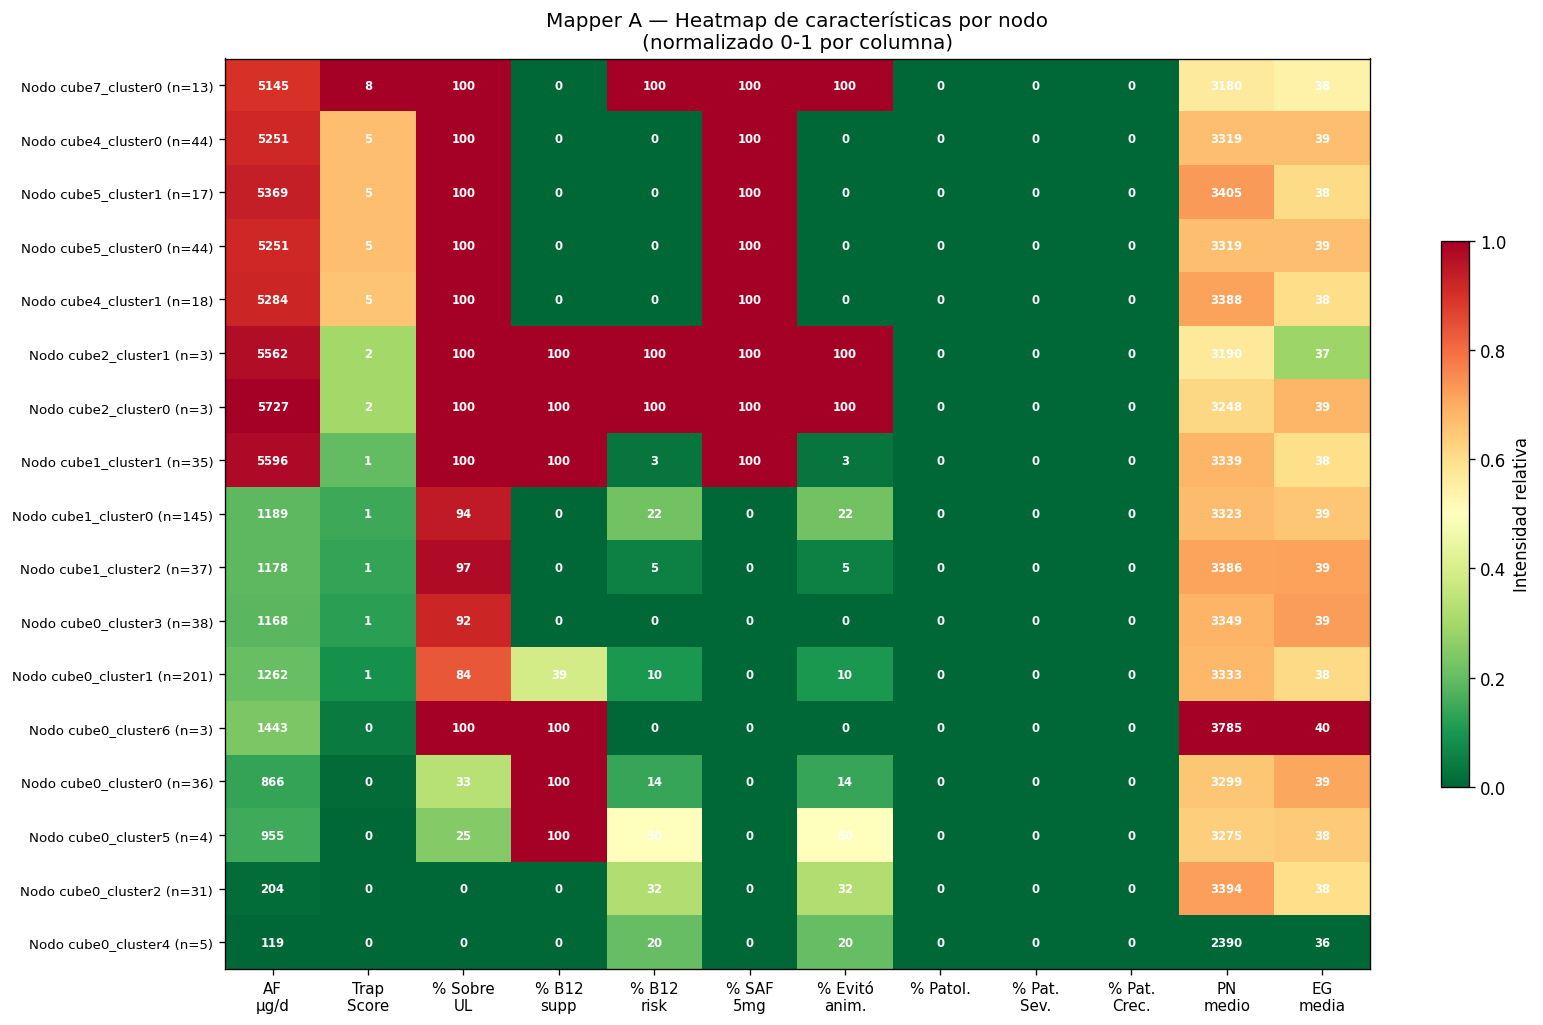

Heatmap guardado en outputs/heatmap_nodos_mapper_a.png


In [36]:
if len(nodos_A) > 0:
    HM_COLS = ["af_mean","trap_score_mean","pct_over_ul","pct_b12_supp",
               "pct_b12_diet_risk","pct_saf_5mg","pct_evito_animal",
               "pct_patologia","pct_pat_severa","pct_pat_crecim","pn_mean","eg_mean"]
    HM_LABS = ["AF\nμg/d","Trap\nScore","% Sobre\nUL","% B12\nsupp",
               "% B12\nrisk","% SAF\n5mg","% Evitó\nanim.",
               "% Patol.","% Pat.\nSev.","% Pat.\nCrec.","PN\nmedio","EG\nmedia"]
 
    data = nodos_A[HM_COLS].copy()
    data_n = (data - data.min()) / (data.max() - data.min() + 1e-9)
 
    fig_h, ax_h = plt.subplots(figsize=(14, max(4, len(nodos_A)*0.45+1)))
    im = ax_h.imshow(data_n.values, aspect="auto", cmap="RdYlGn_r")
    ax_h.set_xticks(range(len(HM_COLS))); ax_h.set_xticklabels(HM_LABS, fontsize=9)
    ax_h.set_yticks(range(len(nodos_A)))
    ax_h.set_yticklabels(
        [f"Nodo {r.nodo} (n={r.n:.0f})" for _, r in nodos_A.iterrows()], fontsize=8)
 
    for i in range(len(nodos_A)):
        for j, col in enumerate(HM_COLS):
            ax_h.text(j, i, f"{data.iloc[i][col]:.0f}",
                      ha="center", va="center", fontsize=7,
                      color="white", fontweight="bold")
 
    plt.colorbar(im, ax=ax_h, label="Intensidad relativa", shrink=0.6)
    ax_h.set_title("Mapper A — Heatmap de características por nodo\n(normalizado 0-1 por columna)",
                    fontsize=12)
    plt.tight_layout()
    plt.savefig("outputs/heatmap_nodos_mapper_a.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Heatmap guardado en outputs/heatmap_nodos_mapper_a.png")

## Comparación Jaccard

Análisis Cruzado — Índice de Jaccard\n\nMide el solapamiento de pacientes entre nodos de distintos Mappers. Jaccard alto (>0.3) indica que el mismo grupo aparece en el Mapper de exposición y en el de outcomes.")
 

In [37]:

def jaccard_pares(g1, g2, n1="G1", n2="G2", min_j=0.05):
    rows = []
    for a, ia in g1["nodes"].items():
        for b, ib in g2["nodes"].items():
            s1, s2 = set(ia), set(ib)
            u = len(s1 | s2)
            if u == 0: continue
            j = len(s1 & s2) / u
            if j >= min_j:
                rows.append({"mapper_1":n1,"nodo_g1":a,
                             "mapper_2":n2,"nodo_g2":b,
                             "jaccard":j,"n_inter":len(s1&s2)})
    return pd.DataFrame(rows).sort_values("jaccard", ascending=False)
 
pares = [
    (graph_A, graph_B, "A","B"),
    (graph_A, graph_C, "A","C"),
    (graph_A, graph_D, "A","D"),
    (graph_B, graph_C, "B","C"),
    (graph_B, graph_D, "B","D"),
    (graph_C, graph_D, "C","D"),
]
all_j = []
for g1,g2,n1,n2 in pares:
    jdf = jaccard_pares(g1,g2,n1,n2)
    all_j.append(jdf)
    tag = f"J_max={jdf['jaccard'].max():.3f}" if len(jdf) else "sin solapamiento"
    print(f"Mapper {n1} ↔ {n2}: {len(jdf)} pares | {tag}")
 
df_j = pd.concat(all_j, ignore_index=True)
 
print("\n=== TOP 10 PARES CON MAYOR JACCARD ===")
print(df_j.head(10).to_string(index=False, float_format="{:.3f}".format))
 
# Nodos consensus A-B
consensus = df_j[(df_j["mapper_1"]=="A")&(df_j["mapper_2"]=="B")&(df_j["jaccard"]>0.2)]
if len(consensus):
    print(f"\nNodos consensus A↔B (J>0.2): {len(consensus)}")
    for _, r in consensus.iterrows():
        pa = nodos_A[nodos_A["nodo"]==r["nodo_g1"]]
        if len(pa):
            p = pa.iloc[0]
            print(f"  A={r['nodo_g1']}↔B={r['nodo_g2']}: "
                  f"J={r['jaccard']:.2f}, n={r['n_inter']}, "
                  f"AF={p['af_mean']:.0f}μg, patol={p['pct_patologia']:.1f}%")
 
df_j.to_csv("outputs/jaccard_cross.csv", index=False)
print("\nJaccard guardado en outputs/jaccard_cross.csv")

Mapper A ↔ B: 25 pares | J_max=0.532
Mapper A ↔ C: 57 pares | J_max=0.650
Mapper A ↔ D: 124 pares | J_max=0.200
Mapper B ↔ C: 54 pares | J_max=0.417
Mapper B ↔ D: 83 pares | J_max=0.134
Mapper C ↔ D: 162 pares | J_max=0.167

=== TOP 10 PARES CON MAYOR JACCARD ===
mapper_1        nodo_g1 mapper_2        nodo_g2  jaccard  n_inter
       A cube0_cluster1        B cube1_cluster0    0.532      189
       A cube1_cluster0        B cube1_cluster0    0.423      145
       A cube1_cluster1        B cube6_cluster0    0.346       18
       A cube0_cluster1        B cube0_cluster0    0.285      100
       A cube1_cluster0        B cube0_cluster0    0.278       86
       A cube5_cluster0        B cube5_cluster0    0.275       42
       A cube4_cluster0        B cube5_cluster0    0.275       42
       A cube1_cluster1        B cube5_cluster0    0.224       34
       A cube4_cluster0        B cube4_cluster0    0.219       14
       A cube5_cluster0        B cube4_cluster0    0.219       14

Nodos con

## Subgrupo crítico

Análisis Subgrupo Crítico\n\n**Definición:** mujeres que evitaron alimentos animales (sin B12 dietaria) Y no tomaron MAF con B12 Y tienen exposición relevante a AF → máximo riesgo de trampa de folato.")


Grupo crítico   (evitó animales + sin B12 supp): n = 83
Grupo control   (consume animales + con B12 supp): n = 192

Variable                     Crítico    Control    p-valor
----------------------------------------------------------
  PN hijo (g)                 3330.4     3330.9     0.5504 n.s.
  EG hijo (sem)                 38.7       38.2     0.1695 n.s.
  patologia_any                  0.1        0.1     0.5100 n.s.
  trap_score                     3.4        0.6     0.0000 ***
  af_total                    2720.2     2648.6     0.6016 n.s.

Distribución patología RN — grupo crítico (n=83)
  [0] Sin patología        n=79  (95.2%)
  [1] Alergia              n=3  (3.6%)
  [2] TEA                  n=1  (1.2%)


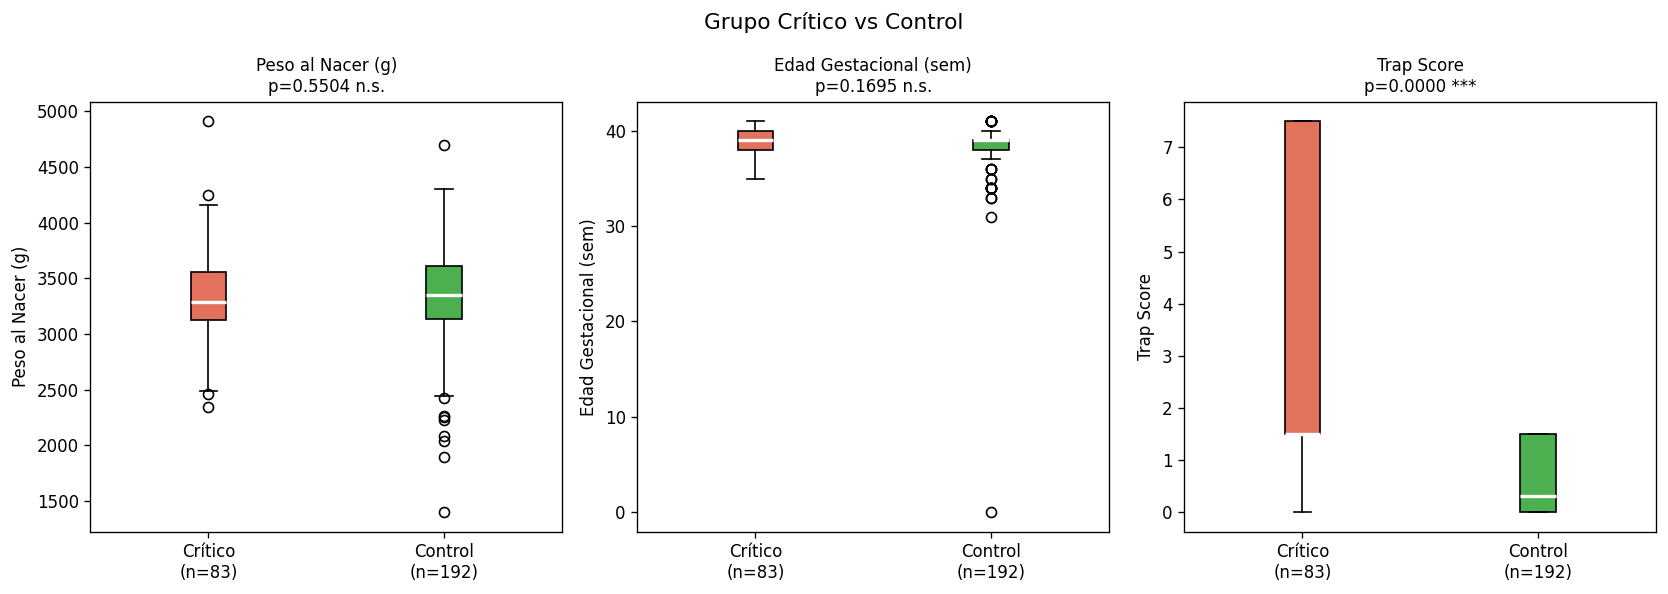

Boxplots guardados en outputs/subgrupo_critico.png


In [38]:
GC_mask   = (df["evito_animal"]==1) & (df["b12_via_supp"]==0) & (df["af_total"]>400)
CTRL_mask = (df["evito_animal"]==0) & (df["b12_via_supp"]==1)
 
gc   = df[GC_mask].copy()
ctrl = df[CTRL_mask].copy()
print(f"Grupo crítico   (evitó animales + sin B12 supp): n = {len(gc)}")
print(f"Grupo control   (consume animales + con B12 supp): n = {len(ctrl)}")
 
# ── Comparación outcomes ──────────────────────────────────────────────────────
vars_comp = ["PN hijo (g)","EG hijo (sem)","patologia_any","trap_score","af_total"]
print(f"\n{'Variable':<25} {'Crítico':>10} {'Control':>10} {'p-valor':>10}")
print("-" * 58)
for v in vars_comp:
    if v not in df.columns: continue
    a, b = gc[v].dropna(), ctrl[v].dropna()
    if len(a)>1 and len(b)>1:
        _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
        print(f"  {v:<23} {a.mean():>10.1f} {b.mean():>10.1f} {p:>10.4f} {sig}")
 
# ── Distribución de patologías en grupo crítico ───────────────────────────────
if len(gc) > 0:
    PAT_MAP = {0:"Sin patología",1:"Alergia",2:"TEA",3:"Cardíaca",
               4:"Pulmonar",5:"Digestiva",6:"Renal",7:"PEG",
               8:"Prematuro",9:"Malformación",10:"Parálisis"}
    print(f"\nDistribución patología RN — grupo crítico (n={len(gc)})")
    for code_p, count in gc["Patología RN"].value_counts().sort_index().items():
        lab = PAT_MAP.get(int(code_p), f"Código {int(code_p)}")
        print(f"  [{int(code_p)}] {lab:<20} n={count}  ({count/len(gc)*100:.1f}%)")
 
# ── Boxplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Grupo Crítico vs Control", fontsize=13)
 
for ax, var, lab in zip(axes,
    ["PN hijo (g)","EG hijo (sem)","trap_score"],
    ["Peso al Nacer (g)","Edad Gestacional (sem)","Trap Score"]):
    a_d, b_d = gc[var].dropna(), ctrl[var].dropna()
    bp = ax.boxplot([a_d, b_d],
                    labels=[f"Crítico\n(n={len(a_d)})", f"Control\n(n={len(b_d)})"],
                    patch_artist=True)
    bp["boxes"][0].set_facecolor("#E2725B")
    bp["boxes"][1].set_facecolor("#4CAF50")
    for m in bp["medians"]: m.set_color("white"); m.set_linewidth(2)
    if len(a_d)>1 and len(b_d)>1:
        _, p = stats.mannwhitneyu(a_d, b_d, alternative="two-sided")
        sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
        ax.set_title(f"{lab}\np={p:.4f} {sig}", fontsize=10)
    else:
        ax.set_title(lab, fontsize=10)
    ax.set_ylabel(lab)
 
plt.tight_layout()
plt.savefig("outputs/subgrupo_critico.png", bbox_inches="tight", dpi=150)
plt.show()
print("Boxplots guardados en outputs/subgrupo_critico.png")